## Exploratory Data Analysis

1.Understanding the Dataset

In [21]:
## 1. Load the data
import pandas as pd

customers_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_customers_dataset.csv")

geolocation_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_geolocation_dataset.csv")

order_items_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_order_items_dataset.csv")

order_payments_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_order_payments_dataset.csv")

order_reviews_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_order_reviews_dataset.csv")

orders_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_orders_dataset.csv")

products_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_products_dataset.csv")

sellers_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_sellers_dataset.csv")

category_translation_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\product_category_name_translation.csv")

print("All 9 datasets loaded successfully!")

All 9 datasets loaded successfully!


In [22]:
##2.Check the shape
print(df.shape)


(71, 2)


In [23]:
##3.Check column names 
print(df.columns)


Index(['product_category_name', 'product_category_name_english'], dtype='str')


In [24]:
## 4. Identify data types
print(df.dtypes)

product_category_name            str
product_category_name_english    str
dtype: object


In [25]:
## 5.Check for missing values
(df.isnull().sum())

product_category_name            0
product_category_name_english    0
dtype: int64

In [26]:
## 6.Check for duplicates
(df.duplicated().sum())

np.int64(0)

In [27]:
## 7. Get summary statistics
(df.describe())

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [29]:
## 8.  Check unique values
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Products": products_df,
    "Sellers": sellers_df,
    "Category Translation": category_translation_df
}

for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for col in data.columns:
        print(f"{col}: {data[col].nunique()} unique values")


Customers
customer_id: 99441 unique values
customer_unique_id: 96096 unique values
customer_zip_code_prefix: 14994 unique values
customer_city: 4119 unique values
customer_state: 27 unique values

Geolocation
geolocation_zip_code_prefix: 19015 unique values
geolocation_lat: 716685 unique values
geolocation_lng: 717097 unique values
geolocation_city: 8011 unique values
geolocation_state: 27 unique values

Order Items
order_id: 98666 unique values
order_item_id: 21 unique values
product_id: 32951 unique values
seller_id: 3095 unique values
shipping_limit_date: 54615 unique values
price: 5968 unique values
freight_value: 6999 unique values

Order Payments
order_id: 99440 unique values
payment_sequential: 29 unique values
payment_type: 5 unique values
payment_installments: 24 unique values
payment_value: 29077 unique values

Order Reviews
review_id: 98410 unique values
order_id: 98673 unique values
review_score: 5 unique values
review_comment_title: 4519 unique values
review_comment_messa

In [ ]:
## 9.Check data balance (for classification) 
Step 1: Decide your classification target

For your Cart2Insights project, if you want to predict whether an order was delivered late/on time, you can use your orders_df dataset and the delivery_performance column you created earlier.

In [31]:
print(orders_df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [32]:
orders_df['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
If your goal is late vs on-time delivery

Then delivery_performance needs to be created first.

In [34]:
orders_df['order_delivered_customer_date'] = pd.to_datetime(
    orders_df['order_delivered_customer_date'],
    dayfirst=True,
    errors='coerce'
)

orders_df['order_estimated_delivery_date'] = pd.to_datetime(
    orders_df['order_estimated_delivery_date'],
    dayfirst=True,
    errors='coerce'
)

In [35]:
print(orders_df[['order_delivered_customer_date',
                 'order_estimated_delivery_date']].head())

  order_delivered_customer_date order_estimated_delivery_date
0           2017-10-10 21:25:00                    2017-10-18
1           2018-08-07 15:27:00                    2018-08-13
2           2018-08-17 18:06:00                    2018-09-04
3           2017-12-02 00:28:00                    2017-12-15
4           2018-02-16 18:17:00                    2018-02-26


In [36]:
orders_df['delivery_performance'].value_counts()

delivery_performance
On Time    96476
Unknown     2965
Name: count, dtype: int64

In [37]:
orders_df['delivery_performance'].value_counts(normalize=True) * 100

delivery_performance
On Time    97.018332
Unknown     2.981668
Name: proportion, dtype: float64

This step lays the foundation for deeper EDA, including visualization, outlier detection, correlation analysis, and feature engineering. 🚀


 2. Handling Missing Values

In [ ]:
Missing values in a dataset can cause problems in analysis and modeling. How we handle missing data depends on the type of data and the reasons why values are missing.

In [38]:
##1. Identify Missing Values
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(data.isnull().sum())


Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Order Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Order Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Orders
order_id

In [40]:
## Check missing-value percentage
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    missing_percentage = (data.isnull().sum() / len(data)) * 100

    print(missing_percentage[missing_percentage > 0])


Customers
Series([], dtype: float64)

Geolocation
Series([], dtype: float64)

Order Items
Series([], dtype: float64)

Order Payments
Series([], dtype: float64)

Order Reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

Orders
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
dtype: float64

Products
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

Sellers
Series([], dtype: float64)

Category Translation
Series([], dtype: float64)


In [ ]:
## 2️⃣ Understand the Type of Missing Data
| Type     | Meaning                                                | Olist example                                            |
| -------- | ------------------------------------------------------ | -------------------------------------------------------- |
| **MCAR** | Missing purely by chance                               | Randomly missing customer information                    |
| **MAR**  | Missingness related to another observed column         | Missing delivery date associated with order status       |
| **MNAR** | Missingness related to the missing value/reason itself | Customer deliberately doesn't provide a particular value |


In [41]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def missing_data_analysis(df, dataset_name):
    
    results = []

    for col in df.columns:
        
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100

        # No missing values
        if missing_count == 0:
            results.append([
                dataset_name,
                col,
                missing_count,
                round(missing_pct, 2),
                "No Missing Values",
                "No analysis required"
            ])
            continue

        # Create missing indicator
        missing_flag = df[col].isnull()

        # Find other columns associated with missingness
        associated_columns = []

        for other_col in df.columns:
            if other_col == col:
                continue

            try:
                if df[other_col].nunique(dropna=True) <= 50:

                    temp = pd.crosstab(
                        df[other_col],
                        missing_flag
                    )

                    if temp.shape[0] > 1 and temp.shape[1] > 1:
                        chi2, p_value, _, _ = chi2_contingency(temp)

                        if p_value < 0.05:
                            associated_columns.append(other_col)

            except:
                pass

        # Practical classification
        if associated_columns:
            missing_type = "Potential MAR"
            reason = "Missingness is associated with: " + ", ".join(
                associated_columns[:5]
            )
        else:
            missing_type = "Potential MCAR"
            reason = "No strong association found with tested categorical variables"

        results.append([
            dataset_name,
            col,
            missing_count,
            round(missing_pct, 2),
            missing_type,
            reason
        ])

    return pd.DataFrame(
        results,
        columns=[
            "Dataset",
            "Column",
            "Missing Count",
            "Missing %",
            "Missing Type",
            "Reason"
        ]
    )

In [42]:
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Products": products_df,
    "Sellers": sellers_df,
    "Category Translation": category_translation_df
}

In [43]:
all_missing_results = []

for name, data in datasets.items():
    result = missing_data_analysis(data, name)
    all_missing_results.append(result)

missing_analysis = pd.concat(
    all_missing_results,
    ignore_index=True
)

missing_analysis

,Dataset,Column,Missing Count,Missing %,Missing Type,Reason
0,Customers,customer_id,0,0.00,No Missing Values,No analysis required
1,Customers,customer_unique_id,0,0.00,No Missing Values,No analysis required
2,Customers,customer_zip_code_prefix,0,0.00,No Missing Values,No analysis required
3,Customers,customer_city,0,0.00,No Missing Values,No analysis required
4,Customers,customer_state,0,0.00,No Missing Values,No analysis required
5,Geolocation,geolocation_zip_code_prefix,0,0.00,No Missing Values,No analysis required
6,Geolocation,geolocation_lat,0,0.00,No Missing Values,No analysis required
7,Geolocation,geolocation_lng,0,0.00,No Missing Values,No analysis required
8,Geolocation,geolocation_city,0,0.00,No Missing Values,No analysis required
9,Geolocation,geolocation_state,0,0.00,No Missing Values,No analysis required


In [44]:
missing_analysis[
    missing_analysis["Missing Count"] > 0
]

,Dataset,Column,Missing Count,Missing %,Missing Type,Reason
25,Order Reviews,review_comment_title,87656,88.34,Potential MAR,Missingness is associated with: review_score
26,Order Reviews,review_comment_message,58247,58.70,Potential MAR,Missingness is associated with: review_score
33,Orders,order_approved_at,160,0.16,Potential MAR,"Missingness is associated with: order_status, ..."
34,Orders,order_delivered_carrier_date,1783,1.79,Potential MAR,"Missingness is associated with: order_status, ..."
35,Orders,order_delivered_customer_date,2965,2.98,Potential MAR,"Missingness is associated with: order_status, ..."
39,Products,product_category_name,610,1.85,Potential MCAR,No strong association found with tested catego...
40,Products,product_name_lenght,610,1.85,Potential MCAR,No strong association found with tested catego...
41,Products,product_description_lenght,610,1.85,Potential MCAR,No strong association found with tested catego...
42,Products,product_photos_qty,610,1.85,Potential MCAR,No strong association found with tested catego...
43,Products,product_weight_g,2,0.01,Potential MCAR,No strong association found with tested catego...


In [ ]:
Important: MNAR

The code above can identify potential MCAR/MAR, but it cannot automatically prove MNAR.

For your Olist data, MNAR should only be assigned when you have a business/domain reason that the missingness itself is related to the unavailable value.

For example:

order_delivered_customer_date

being missing because an order was canceled does not automatically mean MNAR. It may simply be structurally missing because no delivery occurred.

5. For your report, use this interpretation
Classification	How to interpret
No Missing	Column contains no missing values
Potential MCAR	No tested observed variable shows a significant relationship with missingness
Potential MAR	Missingness is significantly associated with another observed variable
Potential MNAR	Requires domain/business evidence that missingness depends on the unavailable value itself
One correction to the usual teaching

Don't write in your report:

"order_delivered_customer_date is MNAR because it is missing."

That conclusion isn't justified from the data alone.

Instead, write something like:

"Missingness was assessed using missingness indicators and relationships with observed variables. Columns showing significant associations with observed categorical variables were flagged as potential MAR. MCAR was treated as a provisional classification where no tested association was detected. MNAR cannot be established from the observed dataset alone and requires domain knowledge or additional information."

3️⃣ Handle Missing Values

In [ ]:
(A) Removing Missing Values

In [45]:
for name, data in datasets.items():
    missing_pct = (data.isnull().sum() / len(data)) * 100

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(missing_pct[missing_pct > 50])


Customers
Series([], dtype: float64)

Geolocation
Series([], dtype: float64)

Order Items
Series([], dtype: float64)

Order Payments
Series([], dtype: float64)

Order Reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

Orders
Series([], dtype: float64)

Products
Series([], dtype: float64)

Sellers
Series([], dtype: float64)

Category Translation
Series([], dtype: float64)


In [ ]:
Drop Columns

In [46]:
order_reviews_df = order_reviews_df.drop(
    columns=['review_comment_title', 'review_comment_message']
)

In [47]:
print(order_reviews_df.columns.tolist())

['review_id', 'order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']


In [48]:
print(order_reviews_df.isnull().sum())

review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [49]:
for name, data in datasets.items():

    missing_pct = (data.isnull().sum() / len(data)) * 100

    columns_to_drop = missing_pct[missing_pct > 50].index.tolist()

    if columns_to_drop:
        print(f"\n{name}")
        print("Dropping:", columns_to_drop)

        data.drop(columns=columns_to_drop, inplace=True)


Order Reviews
Dropping: ['review_comment_title', 'review_comment_message']


In [50]:
for name, data in datasets.items():
    print(name, data.shape)

Customers (99441, 5)
Geolocation (1000163, 5)
Order Items (112650, 7)
Order Payments (103886, 5)
Order Reviews (99224, 5)
Orders (99441, 9)
Products (32951, 9)
Sellers (3095, 4)
Category Translation (71, 2)


In [ ]:
Columns with more than 50% missing values were considered for removal. In the Olist datasets, review_comment_title (88.34%) and review_comment_message (58.70%) in the Order Reviews dataset exceeded the 50% threshold and were removed. No other dataset contained columns exceeding the 50% missing-value threshold.

In [ ]:
(B) Imputing Missing Values


In [ ]:
Numerical Data


In [51]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    numerical_cols = data.select_dtypes(include='number').columns

    for col in numerical_cols:
        missing = data[col].isnull().sum()

        if missing > 0:
            print(f"{col}: {missing} missing values")


Customers

Geolocation

Order Items

Order Payments

Order Reviews

Orders

Products
product_name_lenght: 610 missing values
product_description_lenght: 610 missing values
product_photos_qty: 610 missing values
product_weight_g: 2 missing values
product_length_cm: 2 missing values
product_height_cm: 2 missing values
product_width_cm: 2 missing values

Sellers

Category Translation


In [52]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    numerical_cols = data.select_dtypes(include='number').columns

    for col in numerical_cols:
        if data[col].isnull().sum() > 0:
            print(
                f"{col} → Missing: {data[col].isnull().sum()}, "
                f"Skewness: {data[col].skew():.2f}"
            )


Customers

Geolocation

Order Items

Order Payments

Order Reviews

Orders

Products
product_name_lenght → Missing: 610, Skewness: -0.90
product_description_lenght → Missing: 610, Skewness: 1.96
product_photos_qty → Missing: 610, Skewness: 2.19
product_weight_g → Missing: 2, Skewness: 3.60
product_length_cm → Missing: 2, Skewness: 1.75
product_height_cm → Missing: 2, Skewness: 2.14
product_width_cm → Missing: 2, Skewness: 1.67

Sellers

Category Translation


In [ ]:
| Column                       | Missing | Skewness | Treatment |
| ---------------------------- | ------: | -------: | --------- |
| `product_name_lenght`        |     610 |    -0.90 | Median    |
| `product_description_lenght` |     610 |     1.96 | Median    |
| `product_photos_qty`         |     610 |     2.19 | Median    |
| `product_weight_g`           |       2 |     3.60 | Median    |
| `product_length_cm`          |       2 |     1.75 | Median    |
| `product_height_cm`          |       2 |     2.14 | Median    |
| `product_width_cm`           |       2 |     1.67 | Median    |


In [ ]:
## Step 1 — Apply median imputation

In [54]:
product_numerical_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in product_numerical_cols:
    products_df[col] = products_df[col].fillna(
        products_df[col].median()
    )

In [55]:
print(products_df[product_numerical_cols].isnull().sum())

product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [56]:
for col in product_numerical_cols:
    print(f"{col}: Median = {products_df[col].median()}")

product_name_lenght: Median = 51.0
product_description_lenght: Median = 595.0
product_photos_qty: Median = 1.0
product_weight_g: Median = 700.0
product_length_cm: Median = 25.0
product_height_cm: Median = 13.0
product_width_cm: Median = 20.0


In [ ]:
Numerical Missing Value Imputation:
Missing numerical values were identified in the Products dataset. The affected columns were product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, and product_width_cm. Since these variables exhibited skewed distributions, median imputation was applied to preserve the central tendency while reducing the influence of extreme values. After imputation, no missing numerical values remained in these columns.

In [ ]:
Categorical Data

In [57]:
for name, data in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    categorical_cols = data.select_dtypes(
        include=['object', 'category']
    ).columns

    for col in categorical_cols:
        missing = data[col].isnull().sum()

        if missing > 0:
            print(f"{col}: {missing} missing values")


Customers

Geolocation

Order Items

Order Payments

Order Reviews

Orders
order_approved_at: 160 missing values
order_delivered_carrier_date: 1783 missing values

Products
product_category_name: 610 missing values

Sellers

Category Translation


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3649597770.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3649597770.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

In [58]:
for name, data in datasets.items():

    categorical_cols = data.select_dtypes(
        include=['object', 'category']
    ).columns

    for col in categorical_cols:

        if data[col].isnull().sum() > 0:

            mode_value = data[col].mode()[0]

            data[col] = data[col].fillna(mode_value)

            print(
                f"{name} → {col} → "
                f"Mode imputation → '{mode_value}'"
            )

Orders → order_approved_at → Mode imputation → '10-01-2018 10:32'
Orders → order_delivered_carrier_date → Mode imputation → '09-05-2018 15:48'
Products → product_category_name → Mode imputation → 'cama_mesa_banho'


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\899970265.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\899970265.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

In [59]:
for name, data in datasets.items():

    categorical_missing = data.select_dtypes(
        include=['object', 'category']
    ).isnull().sum()

    categorical_missing = categorical_missing[
        categorical_missing > 0
    ]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if len(categorical_missing) == 0:
        print("No missing categorical values")
    else:
        print(categorical_missing)


Customers
No missing categorical values

Geolocation
No missing categorical values

Order Items
No missing categorical values

Order Payments
No missing categorical values

Order Reviews
No missing categorical values

Orders
No missing categorical values

Products
No missing categorical values

Sellers
No missing categorical values

Category Translation
No missing categorical values


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2460147224.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_missing = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2460147224.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

In [ ]:
Categorical Missing Value Imputation: Missing values in categorical variables were replaced using mode imputation. The mode, representing the most frequently occurring category, was used to preserve the dominant category distribution. This procedure was applied to categorical columns with missing values across the datasets.

In [ ]:
Time-Series Data


In [ ]:
Forward Fill

In [60]:
## 1. First, identify datetime columns in all 9 datasets
for name, data in datasets.items():

    datetime_cols = data.select_dtypes(
        include=['datetime64[ns]', 'datetime64[ns, UTC]']
    ).columns

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if len(datetime_cols) == 0:
        print("No datetime columns")
    else:
        for col in datetime_cols:
            print(f"{col}: {data[col].isnull().sum()} missing")


Customers
No datetime columns

Geolocation
No datetime columns

Order Items
No datetime columns

Order Payments
No datetime columns

Order Reviews
No datetime columns

Orders
order_delivered_customer_date: 2965 missing
order_estimated_delivery_date: 0 missing

Products
No datetime columns

Sellers
No datetime columns

Category Translation
No datetime columns


In [62]:
## 2. Convert the Olist Orders date columns
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        dayfirst=True,
        errors='coerce'
    )

In [63]:
## 3. Sort Orders by time
orders_df = orders_df.sort_values(
    by='order_purchase_timestamp'
).reset_index(drop=True)

In [64]:
## 4. Check missing time-series values
print(
    orders_df[date_columns].isnull().sum()
)

order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [66]:
## 5. Forward Fill
orders_df[date_columns] = orders_df[date_columns].ffill()

In [67]:
## 6. Backward Fill
orders_df[date_columns] = orders_df[date_columns].bfill()

In [68]:
for name, data in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Find datetime columns
    datetime_cols = data.select_dtypes(
        include=['datetime64[ns]', 'datetime64[ns, UTC]']
    ).columns.tolist()

    if not datetime_cols:
        print("No datetime columns")
        continue

    for col in datetime_cols:

        missing_before = data[col].isnull().sum()

        if missing_before > 0:

            # Forward fill
            data[col] = data[col].ffill()

            missing_after = data[col].isnull().sum()

            print(
                f"{col}: "
                f"Missing before = {missing_before}, "
                f"Missing after = {missing_after}, "
                f"Method = Forward Fill"
            )


Customers
No datetime columns

Geolocation
No datetime columns

Order Items
No datetime columns

Order Payments
No datetime columns

Order Reviews
No datetime columns

Orders
order_delivered_customer_date: Missing before = 2965, Missing after = 0, Method = Forward Fill

Products
No datetime columns

Sellers
No datetime columns

Category Translation
No datetime columns


In [ ]:
Time-Series Missing Value Treatment: Date/time columns were examined for missing values after converting them to appropriate datetime formats. Forward fill and backward fill were considered for sequential time-series data. However, these methods were not blindly applied to order dates because missing delivery-related dates in the Olist dataset may represent valid business conditions such as orders that were not delivered. Therefore, time-series imputation was applied only where the sequential nature of the data justified carrying the previous or next valid observation forward/backward.

In [ ]:
Machine Learning Imputation

In [69]:
from sklearn.impute import KNNImputer

In [70]:
from sklearn.impute import KNNImputer

for name, data in datasets.items():

    numerical_cols = data.select_dtypes(
        include='number'
    ).columns.tolist()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if not numerical_cols:
        print("No numerical columns")
        continue

    missing_cols = [
        col for col in numerical_cols
        if data[col].isnull().sum() > 0
    ]

    if not missing_cols:
        print("No missing numerical values")
        continue

    print("Columns with missing values:", missing_cols)

    imputer = KNNImputer(n_neighbors=5)

    data[numerical_cols] = imputer.fit_transform(
        data[numerical_cols]
    )

    print("KNN Imputation completed")


Customers
No missing numerical values

Geolocation
No missing numerical values

Order Items
No missing numerical values

Order Payments
No missing numerical values

Order Reviews
No missing numerical values

Orders
No numerical columns

Products
No missing numerical values

Sellers
No missing numerical values

Category Translation
No numerical columns


In [71]:
for name, data in datasets.items():

    numerical_missing = data.select_dtypes(
        include='number'
    ).isnull().sum()

    numerical_missing = numerical_missing[
        numerical_missing > 0
    ]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if len(numerical_missing) == 0:
        print("No missing numerical values")
    else:
        print(numerical_missing)


Customers
No missing numerical values

Geolocation
No missing numerical values

Order Items
No missing numerical values

Order Payments
No missing numerical values

Order Reviews
No missing numerical values

Orders
No missing numerical values

Products
No missing numerical values

Sellers
No missing numerical values

Category Translation
No missing numerical values


In [ ]:
KNN Imputation: KNN Imputation with n_neighbors=5 was evaluated as an alternative machine-learning-based technique for numerical missing values. The numerical missing values in the Products dataset had already been addressed using median imputation based on the skewness of the variables. Therefore, no missing numerical values remained for KNN imputation.

In [ ]:
4️⃣ Verify Handling of Missing Values

In [72]:
for name, data in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    missing = data.isnull().sum()

    if missing.sum() == 0:
        print("No missing values remaining")
    else:
        print(missing[missing > 0])


Customers
No missing values remaining

Geolocation
No missing values remaining

Order Items
No missing values remaining

Order Payments
No missing values remaining

Order Reviews
No missing values remaining

Orders
No missing values remaining

Products
No missing values remaining

Sellers
No missing values remaining

Category Translation
No missing values remaining


3.  Removing Duplicates

In [ ]:
Duplicates in a dataset can cause bias in analysis and incorrect model predictions. Removing them ensures data consistency and accuracy

In [73]:
## 1️⃣ Identifying Duplicate Rows
for name, data in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    duplicate_count = data.duplicated().sum()

    print("Duplicate rows:", duplicate_count)


Customers
Duplicate rows: 0

Geolocation
Duplicate rows: 261836

Order Items
Duplicate rows: 0

Order Payments
Duplicate rows: 0

Order Reviews
Duplicate rows: 0

Orders
Duplicate rows: 0

Products
Duplicate rows: 0

Sellers
Duplicate rows: 0

Category Translation
Duplicate rows: 0


In [74]:
## Display duplicate rows
for name, data in datasets.items():

    duplicates = data[data.duplicated()]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if len(duplicates) == 0:
        print("No duplicate rows")
    else:
        print("Duplicate rows:")
        print(duplicates)


Customers
No duplicate rows

Geolocation
Duplicate rows:
         geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
15                              1046       -23.546081       -46.644820   
44                              1046       -23.546081       -46.644820   
65                              1046       -23.546081       -46.644820   
66                              1009       -23.546935       -46.636588   
67                              1046       -23.546081       -46.644820   
...                              ...              ...              ...   
1000153                        99970       -28.343273       -51.873734   
1000154                        99950       -28.070493       -52.011342   
1000159                        99900       -27.877125       -52.224882   
1000160                        99950       -28.071855       -52.014716   
1000162                        99950       -28.070104       -52.018658   

        geolocation_city geolocation_state  
15      

In [75]:
## Display duplicate count
duplicate_summary = []

for name, data in datasets.items():

    duplicate_count = data.duplicated().sum()

    duplicate_summary.append({
        "Dataset": name,
        "Rows": len(data),
        "Duplicate Rows": duplicate_count
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

print(duplicate_summary_df)

                Dataset     Rows  Duplicate Rows
0             Customers    99441               0
1           Geolocation  1000163          261836
2           Order Items   112650               0
3        Order Payments   103886               0
4         Order Reviews    99224               0
5                Orders    99441               0
6              Products    32951               0
7               Sellers     3095               0
8  Category Translation       71               0


In [ ]:
## 2️⃣ Removing Duplicate Rows

In [80]:
## Keep the first occurrence
for name, data in datasets.items():

    before = len(data)

    datasets[name] = data.drop_duplicates(keep='first')

    after = len(datasets[name])

    print(
        f"{name}: Removed {before - after} duplicates | "
        f"Rows remaining: {after}"
    )

Customers: Removed 0 duplicates | Rows remaining: 99441
Geolocation: Removed 0 duplicates | Rows remaining: 738327
Order Items: Removed 0 duplicates | Rows remaining: 112650
Order Payments: Removed 0 duplicates | Rows remaining: 103886
Order Reviews: Removed 0 duplicates | Rows remaining: 99224
Orders: Removed 0 duplicates | Rows remaining: 99441
Products: Removed 0 duplicates | Rows remaining: 32951
Sellers: Removed 0 duplicates | Rows remaining: 3095
Category Translation: Removed 0 duplicates | Rows remaining: 71


In [81]:
## Keep the last occurrence
for name, data in datasets.items():

    before = len(data)

    datasets[name] = data.drop_duplicates(keep='last')

    after = len(datasets[name])

    print(
        f"{name}: Removed {before - after} duplicates | "
        f"Rows remaining: {after}"
    )

Customers: Removed 0 duplicates | Rows remaining: 99441
Geolocation: Removed 0 duplicates | Rows remaining: 738327
Order Items: Removed 0 duplicates | Rows remaining: 112650
Order Payments: Removed 0 duplicates | Rows remaining: 103886
Order Reviews: Removed 0 duplicates | Rows remaining: 99224
Orders: Removed 0 duplicates | Rows remaining: 99441
Products: Removed 0 duplicates | Rows remaining: 32951
Sellers: Removed 0 duplicates | Rows remaining: 3095
Category Translation: Removed 0 duplicates | Rows remaining: 71


In [82]:
## remove ALL copies
for name, data in datasets.items():

    before = len(data)

    datasets[name] = data.drop_duplicates(keep=False)

    after = len(datasets[name])

    print(
        f"{name}: Removed {before - after} rows | "
        f"Rows remaining: {after}"
    )

Customers: Removed 0 rows | Rows remaining: 99441
Geolocation: Removed 0 rows | Rows remaining: 738327
Order Items: Removed 0 rows | Rows remaining: 112650
Order Payments: Removed 0 rows | Rows remaining: 103886
Order Reviews: Removed 0 rows | Rows remaining: 99224
Orders: Removed 0 rows | Rows remaining: 99441
Products: Removed 0 rows | Rows remaining: 32951
Sellers: Removed 0 rows | Rows remaining: 3095
Category Translation: Removed 0 rows | Rows remaining: 71


In [ ]:
3️⃣ Removing Duplicates Based on Specific Columns


In [83]:
for name, data in datasets.items():
    print(f"\n{name}")
    print(data.columns.tolist())


Customers
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Geolocation
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Order Items
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Order Payments
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Order Reviews
['review_id', 'order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']

Orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_performance']

Products
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

In [84]:
customers_df = customers_df.drop_duplicates(
    subset=['customer_id'],
    keep='first'
).reset_index(drop=True)

In [85]:
orders_df = orders_df.drop_duplicates(
    subset=['order_id'],
    keep='first'
).reset_index(drop=True)

In [86]:
order_items_df = order_items_df.drop_duplicates(
    subset=['order_id', 'order_item_id'],
    keep='first'
).reset_index(drop=True)

In [87]:
order_payments_df = order_payments_df.drop_duplicates(
    subset=['order_id', 'payment_sequential'],
    keep='first'
).reset_index(drop=True)

In [88]:
products_df = products_df.drop_duplicates(
    subset=['product_id'],
    keep='first'
).reset_index(drop=True)

In [89]:
sellers_df = sellers_df.drop_duplicates(
    subset=['seller_id'],
    keep='first'
).reset_index(drop=True)

In [90]:
category_translation_df = category_translation_df.drop_duplicates(
    subset=['product_category_name'],
    keep='first'
).reset_index(drop=True)

In [91]:
print(
    customers_df['customer_id'].duplicated().sum()
)

print(
    orders_df['order_id'].duplicated().sum()
)

print(
    products_df['product_id'].duplicated().sum()
)

print(
    sellers_df['seller_id'].duplicated().sum()
)

0
0
0
0


In [97]:
cleaned_datasets = {
    name: data.copy()
    for name, data in datasets.items()
}

In [98]:
for name, data in cleaned_datasets.items():

    before = len(data)

    cleaned_datasets[name] = (
        data
        .drop_duplicates(keep='first')
        .reset_index(drop=True)
    )

    after = len(cleaned_datasets[name])

    print(
        f"{name}: "
        f"Before = {before:,}, "
        f"Removed = {before - after:,}, "
        f"After = {after:,}"
    )

Customers: Before = 99,441, Removed = 0, After = 99,441
Geolocation: Before = 738,327, Removed = 0, After = 738,327
Order Items: Before = 112,650, Removed = 0, After = 112,650
Order Payments: Before = 103,886, Removed = 0, After = 103,886
Order Reviews: Before = 99,224, Removed = 0, After = 99,224
Orders: Before = 99,441, Removed = 0, After = 99,441
Products: Before = 32,951, Removed = 0, After = 32,951
Sellers: Before = 3,095, Removed = 0, After = 3,095
Category Translation: Before = 71, Removed = 0, After = 71


In [99]:
key_columns = {
    'Customers': ['customer_id'],
    'Orders': ['order_id'],
    'Order Items': ['order_id', 'order_item_id'],
    'Order Payments': ['order_id', 'payment_sequential'],
    'Products': ['product_id'],
    'Sellers': ['seller_id']
}

for name, cols in key_columns.items():

    data = cleaned_datasets[name]

    duplicate_count = data.duplicated(
        subset=cols
    ).sum()

    print(
        f"{name}: "
        f"{duplicate_count:,} duplicate key combinations"
    )

Customers: 0 duplicate key combinations
Orders: 0 duplicate key combinations
Order Items: 0 duplicate key combinations
Order Payments: 0 duplicate key combinations
Products: 0 duplicate key combinations
Sellers: 0 duplicate key combinations


In [100]:
geo = cleaned_datasets['Geolocation']

print(geo.columns.tolist())

print(
    geo.duplicated(
        subset=[
            'geolocation_zip_code_prefix',
            'geolocation_lat',
            'geolocation_lng',
            'geolocation_city',
            'geolocation_state'
        ]
    ).sum()
)

['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
0


In [101]:
for name, data in cleaned_datasets.items():

    missing = data.isnull().sum()
    missing = missing[missing > 0]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


Customers
No missing values

Geolocation
No missing values

Order Items
No missing values

Order Payments
No missing values

Order Reviews
No missing values

Orders
No missing values

Products
No missing values

Sellers
No missing values

Category Translation
No missing values


In [102]:
for name, data in cleaned_datasets.items():

    print(
        f"{name}: "
        f"{data.duplicated().sum():,} duplicate rows"
    )

Customers: 0 duplicate rows
Geolocation: 0 duplicate rows
Order Items: 0 duplicate rows
Order Payments: 0 duplicate rows
Order Reviews: 0 duplicate rows
Orders: 0 duplicate rows
Products: 0 duplicate rows
Sellers: 0 duplicate rows
Category Translation: 0 duplicate rows


In [103]:
customers_df = cleaned_datasets['Customers']
geolocation_df = cleaned_datasets['Geolocation']
order_items_df = cleaned_datasets['Order Items']
order_payments_df = cleaned_datasets['Order Payments']
order_reviews_df = cleaned_datasets['Order Reviews']
orders_df = cleaned_datasets['Orders']
products_df = cleaned_datasets['Products']
sellers_df = cleaned_datasets['Sellers']
category_translation_df = cleaned_datasets['Category Translation']

In [104]:
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Products": products_df,
    "Sellers": sellers_df,
    "Category Translation": category_translation_df
}

In [ ]:
Duplicate Removal Based on Specific Columns: Duplicate records were also evaluated using dataset-specific identifier columns. Primary/business key columns such as customer_id, order_id, product_id, and seller_id were checked for duplicate values. Where duplicate keys represented redundant records, duplicates were retained based on the first occurrence using drop_duplicates(subset=..., keep='first'). Composite keys were used for datasets where a single identifier does not uniquely identify a record.

In [ ]:
4️⃣ Removing Duplicates While Ignoring NaN Values


In [105]:
for name, data in datasets.items():

    before = len(data)

    datasets[name] = data.drop_duplicates(
        keep='first',
        ignore_index=True
    )

    after = len(datasets[name])

    print(
        f"{name}: "
        f"Before = {before:,}, "
        f"Removed = {before - after:,}, "
        f"After = {after:,}"
    )

Customers: Before = 99,441, Removed = 0, After = 99,441
Geolocation: Before = 738,327, Removed = 0, After = 738,327
Order Items: Before = 112,650, Removed = 0, After = 112,650
Order Payments: Before = 103,886, Removed = 0, After = 103,886
Order Reviews: Before = 99,224, Removed = 0, After = 99,224
Orders: Before = 99,441, Removed = 0, After = 99,441
Products: Before = 32,951, Removed = 0, After = 32,951
Sellers: Before = 3,095, Removed = 0, After = 3,095
Category Translation: Before = 71, Removed = 0, After = 71


In [106]:
df_cleaned = df.drop_duplicates(ignore_index=True)

In [107]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
66    False
67    False
68    False
69    False
70    False
Length: 71, dtype: bool

In [108]:
df.drop_duplicates()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [109]:
data.drop_duplicates(
    keep='first',
    ignore_index=True
)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [ ]:
5️⃣ Verify Duplicate Removal

In [110]:
for name, data in datasets.items():

    duplicate_count = data.duplicated().sum()

    print(
        f"{name}: "
        f"{duplicate_count} duplicate rows remaining"
    )

Customers: 0 duplicate rows remaining
Geolocation: 0 duplicate rows remaining
Order Items: 0 duplicate rows remaining
Order Payments: 0 duplicate rows remaining
Order Reviews: 0 duplicate rows remaining
Orders: 0 duplicate rows remaining
Products: 0 duplicate rows remaining
Sellers: 0 duplicate rows remaining
Category Translation: 0 duplicate rows remaining


In [111]:
all_duplicates_removed = True

for name, data in datasets.items():

    duplicate_count = data.duplicated().sum()

    if duplicate_count == 0:
        print(f"✅ {name}: No duplicate rows")
    else:
        print(f"❌ {name}: {duplicate_count} duplicates remain")
        all_duplicates_removed = False

print("\nFinal verification:", all_duplicates_removed)

✅ Customers: No duplicate rows
✅ Geolocation: No duplicate rows
✅ Order Items: No duplicate rows
✅ Order Payments: No duplicate rows
✅ Order Reviews: No duplicate rows
✅ Orders: No duplicate rows
✅ Products: No duplicate rows
✅ Sellers: No duplicate rows
✅ Category Translation: No duplicate rows

Final verification: True


In [ ]:
Verification of Duplicate Removal: After removing duplicate records, the duplicated().sum() function was used to verify the cleaned datasets. The verification confirmed that no exact duplicate rows remained in the datasets.

In [ ]:
4. Generating Summary Statistics

In [ ]:
Summary statistics help understand the distribution, central tendency, and variability of the dataset. These insights guide data preprocessing, feature engineering, and model selection.

In [ ]:
1️⃣ Summary Statistics for Numerical Data

In [112]:
for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(data.describe())


Customers
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

Geolocation
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                738327.000000    738327.000000    738327.000000
mean                  38316.232394       -20.998342       -46.461109
std                   30632.540650         5.892333         4.393714
min                    1001.000000       -36.605374      -101.466766
25%                   12600.000000       -23.603061       -48.867871
50%                   29144.000000       -22.873587       -46.647281
75%                   65950.000000       -19.923332       -43.836979
max                   99990.000000        45.065933       121.105394

Order Items
       order_item_id          price  freight_value
cou

In [ ]:
2️⃣ Summary Statistics for Categorical Data

In [113]:
for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(data.describe(include='object'))


Customers


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))


                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             SP  
freq           15540          41746  

Geolocation
       geolocation_city geolocation_state
count            738327            738327
unique             8011                27
top           sao paulo                SP
freq              79926            285973

Order Items
                                order_id                        product_id  \
count                             112650                            112650   
unique                     

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

                                order_id payment_type
count                             103886       103886
unique                             99440            5
top     fa65dad1b0e818e3ccc5cb0e39231352  credit_card
freq                                  29        76795

Order Reviews
                               review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     c444278834184f72b1484dfe47de7f97  c88b1d1b157a9999ce368f218a407141   
freq                                   3                                 3   

       review_creation_date review_answer_timestamp  
count                 99224                   99224  
unique                  636                   88867  
top        19-12-2017 00:00        12-08-2017 14:35  
freq                    463                       6  

Orders


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status delivery_performance  
count         99441                99441  
unique            8                    2  
top       delivered              On Time  
freq          96478                96476  

Products
                              product_id product_category_name
count                              32951                 32951
unique                             32951                    73
top     07f01b6fcacc1b187a71e5074199db2d       cama_mesa_banho
freq                                   1                  3639

Sellers
                               seller_id seller_city seller_

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3446101111.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

In [ ]:
3️⃣ Get Both Numerical + Categorical Statistics

In [114]:
for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print("\n--- Numerical Summary ---")
    print(data.describe())

    print("\n--- Categorical Summary ---")
    print(data.describe(include='object'))


Customers

--- Numerical Summary ---
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

--- Categorical Summary ---
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             SP  
freq           15540          41746  

Geolocation

--- Numerical Summary ---


C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))


       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                738327.000000    738327.000000    738327.000000
mean                  38316.232394       -20.998342       -46.461109
std                   30632.540650         5.892333         4.393714
min                    1001.000000       -36.605374      -101.466766
25%                   12600.000000       -23.603061       -48.867871
50%                   29144.000000       -22.873587       -46.647281
75%                   65950.000000       -19.923332       -43.836979
max                   99990.000000        45.065933       121.105394

--- Categorical Summary ---
       geolocation_city geolocation_state
count            738327            738327
unique             8011                27
top           sao paulo                SP
freq              79926            285973

Order Items

--- Numerical Summary ---
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.00000

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

       payment_sequential  payment_installments  payment_value
count       103886.000000         103886.000000  103886.000000
mean             1.092679              2.853349     154.100380
std              0.706584              2.687051     217.494064
min              1.000000              0.000000       0.000000
25%              1.000000              1.000000      56.790000
50%              1.000000              1.000000     100.000000
75%              1.000000              4.000000     171.837500
max             29.000000             24.000000   13664.080000

--- Categorical Summary ---
                                order_id payment_type
count                             103886       103886
unique                             99440            5
top     fa65dad1b0e818e3ccc5cb0e39231352  credit_card
freq                                  29        76795

Order Reviews

--- Numerical Summary ---
       review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

                               review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     c444278834184f72b1484dfe47de7f97  c88b1d1b157a9999ce368f218a407141   
freq                                   3                                 3   

       review_creation_date review_answer_timestamp  
count                 99224                   99224  
unique                  636                   88867  
top        19-12-2017 00:00        12-08-2017 14:35  
freq                    463                       6  

Orders

--- Numerical Summary ---
         order_purchase_timestamp           order_approved_at  \
count                       99441                       99441   
mean   2017-12-31 08:42:43.256403  2017-12-31 18:57:21.050472   
min           2016-09-04 21:15:00         2016-09-15 12:16:00   
25%           2017-09-12 14:46:00         20

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include='object'))
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\847738990.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

In [ ]:
4️⃣ Better: Generate a compact summary for all 9 datasets

In [115]:
for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(f"DATASET: {name}")
    print(f"Rows: {data.shape[0]:,}")
    print(f"Columns: {data.shape[1]:,}")
    print("=" * 80)

    print("\nNumerical columns:")
    print(data.select_dtypes(include='number').columns.tolist())

    print("\nCategorical columns:")
    print(data.select_dtypes(include='object').columns.tolist())


DATASET: Customers
Rows: 99,441
Columns: 5

Numerical columns:
['customer_zip_code_prefix']

Categorical columns:
['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']

DATASET: Geolocation
Rows: 738,327
Columns: 5

Numerical columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']

Categorical columns:
['geolocation_city', 'geolocation_state']

DATASET: Order Items
Rows: 112,650
Columns: 7

Numerical columns:
['order_item_id', 'price', 'freight_value']

Categorical columns:
['order_id', 'product_id', 'seller_id', 'shipping_limit_date']

DATASET: Order Payments
Rows: 103,886
Columns: 5

Numerical columns:
['payment_sequential', 'payment_installments', 'payment_value']

Categorical columns:
['order_id', 'payment_type']

DATASET: Order Reviews
Rows: 99,224
Columns: 5

Numerical columns:
['review_score']

Categorical columns:
['review_id', 'order_id', 'review_creation_date', 'review_answer_timestamp']

DATASET: Orders
Rows: 99,441
Columns: 9

Nume

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\435543978.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.select_dtypes(include='object').columns.tolist())
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\435543978.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.

In [ ]:
Summary Statistics: Descriptive statistics were generated for all nine datasets using the Pandas .describe() method. Numerical variables were summarized using count, mean, standard deviation, minimum, quartiles, and maximum values. Categorical variables were summarized using count, number of unique categories, most frequent category, and its frequency. These statistics were used to understand the central tendency, variability, distribution, and category frequencies of the cleaned datasets.

5. Univariate Analysis

In [ ]:
1️⃣ Numerical Data Analysis

In [116]:
import pandas as pd
import numpy as np

for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(f"UNIVARIATE NUMERICAL ANALYSIS — {name}")
    print("=" * 80)

    numerical_cols = data.select_dtypes(include='number').columns

    if len(numerical_cols) == 0:
        print("No numerical columns")
        continue

    for col in numerical_cols:

        print(f"\n--- {col} ---")

        # Summary statistics
        print(data[col].describe())

        # Skewness
        print(f"Skewness : {data[col].skew():.3f}")

        # Kurtosis
        print(f"Kurtosis : {data[col].kurt():.3f}")

        # IQR Outlier Detection
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ]

        print(f"Q1 : {Q1:.3f}")
        print(f"Q3 : {Q3:.3f}")
        print(f"IQR : {IQR:.3f}")
        print(f"Lower Bound : {lower_bound:.3f}")
        print(f"Upper Bound : {upper_bound:.3f}")
        print(f"Outliers : {len(outliers):,}")


UNIVARIATE NUMERICAL ANALYSIS — Customers

--- customer_zip_code_prefix ---
count    99441.000000
mean     35137.474583
std      29797.938996
min       1003.000000
25%      11347.000000
50%      24416.000000
75%      58900.000000
max      99990.000000
Name: customer_zip_code_prefix, dtype: float64
Skewness : 0.779
Kurtosis : -0.788
Q1 : 11347.000
Q3 : 58900.000
IQR : 47553.000
Lower Bound : -59982.500
Upper Bound : 130229.500
Outliers : 0

UNIVARIATE NUMERICAL ANALYSIS — Geolocation

--- geolocation_zip_code_prefix ---
count    738327.000000
mean      38316.232394
std       30632.540650
min        1001.000000
25%       12600.000000
50%       29144.000000
75%       65950.000000
max       99990.000000
Name: geolocation_zip_code_prefix, dtype: float64
Skewness : 0.619
Kurtosis : -1.044
Q1 : 12600.000
Q3 : 65950.000
IQR : 53350.000
Lower Bound : -67425.000
Upper Bound : 145975.000
Outliers : 0

--- geolocation_lat ---
count    738327.000000
mean        -20.998342
std           5.892333
mi

In [ ]:
2️⃣ Histograms

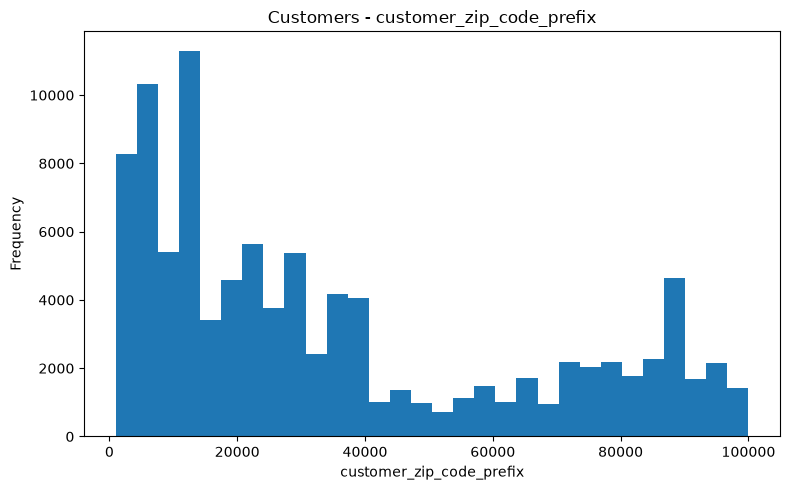

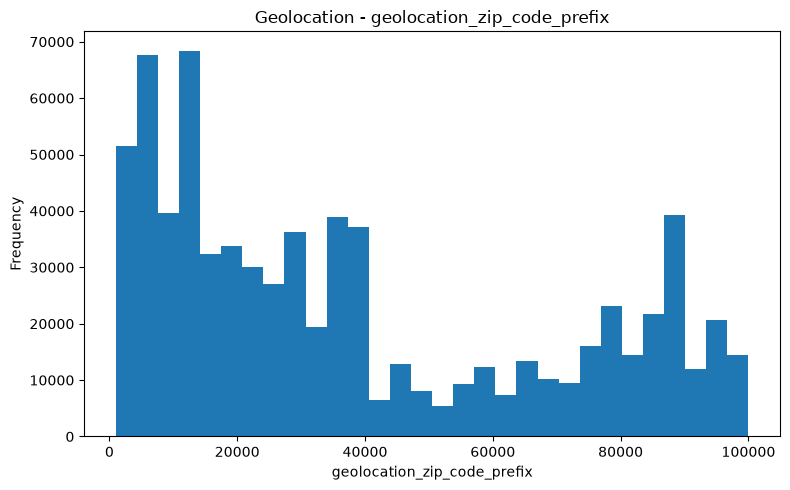

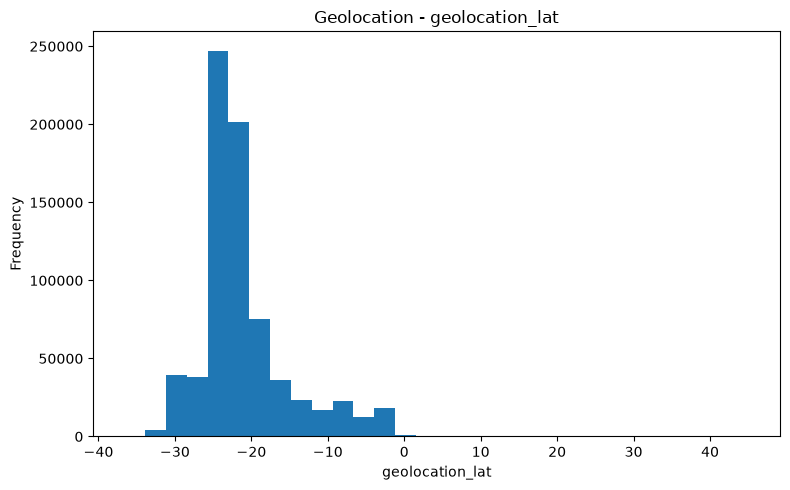

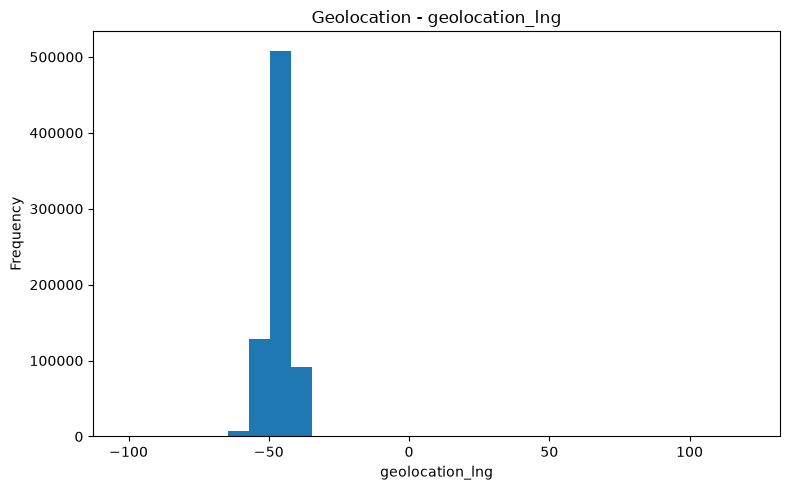

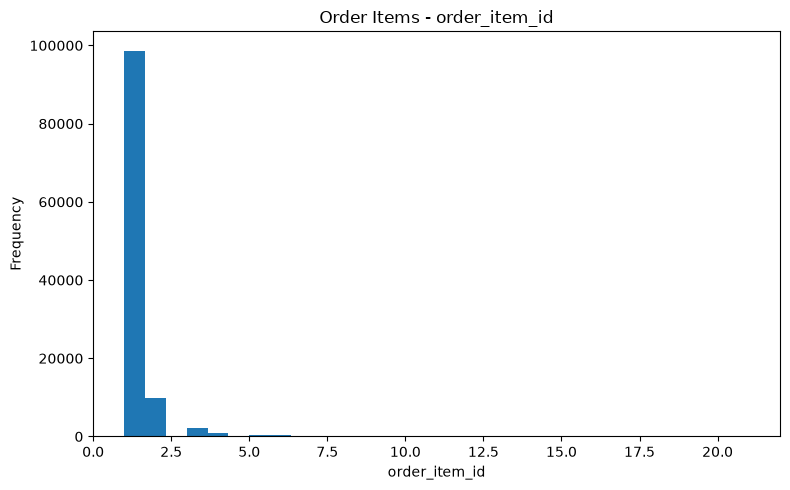

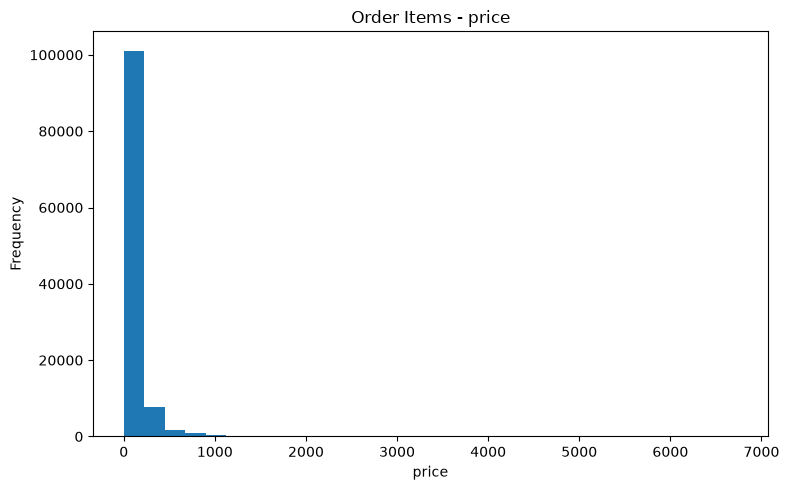

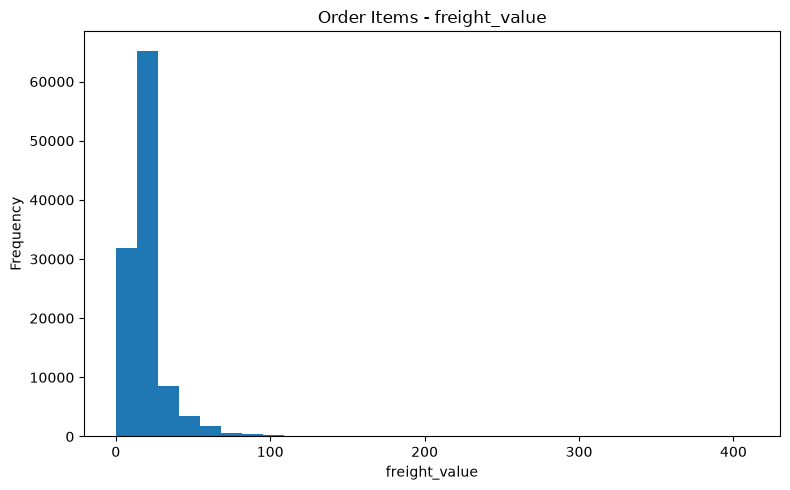

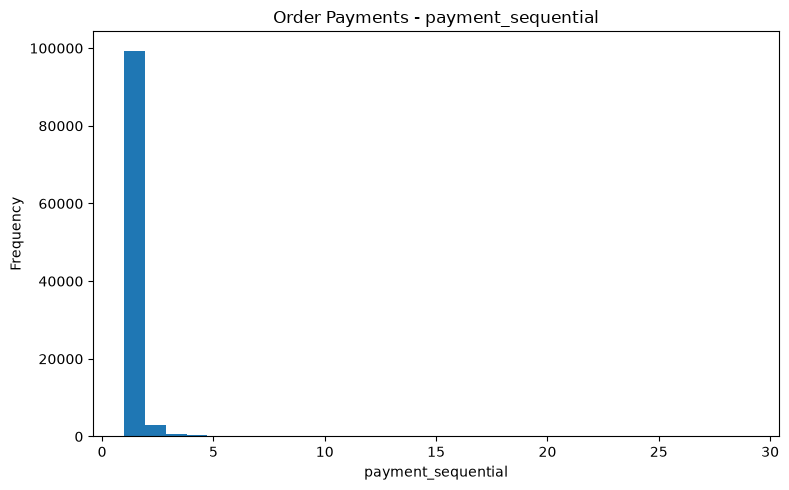

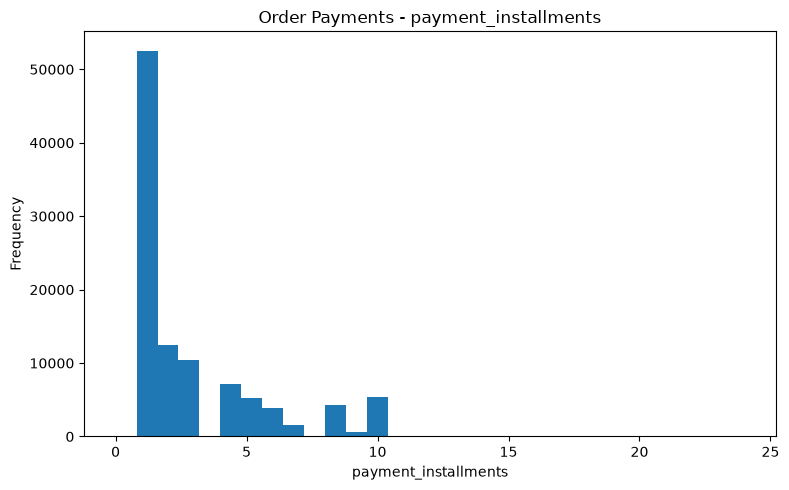

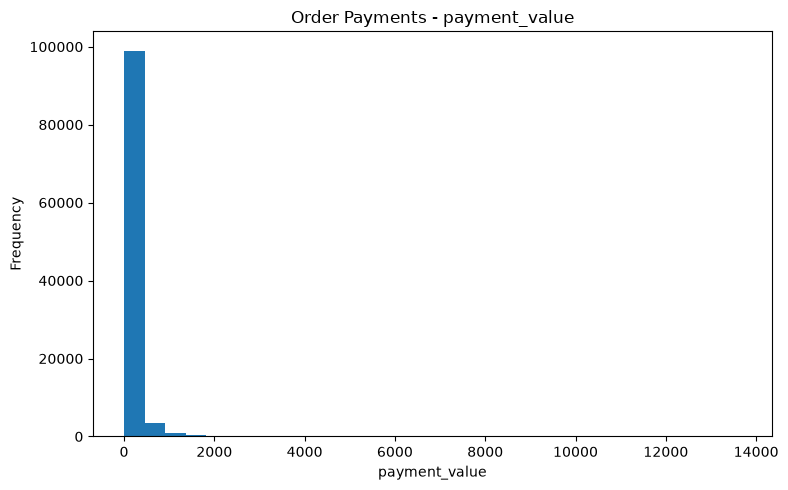

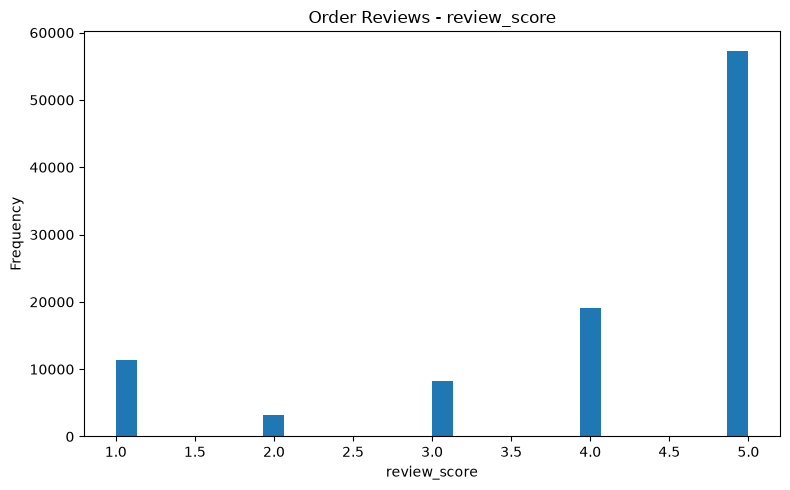

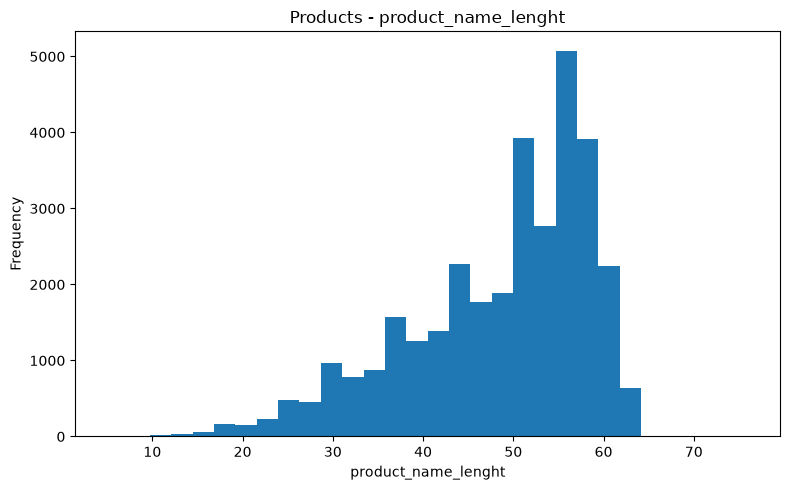

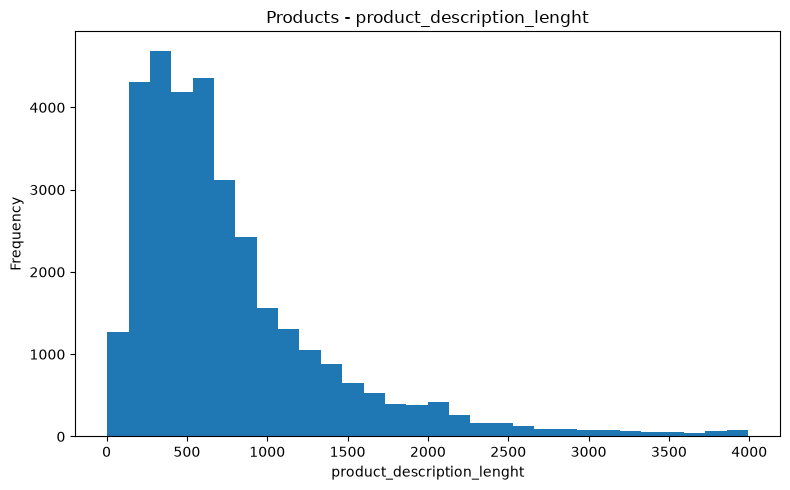

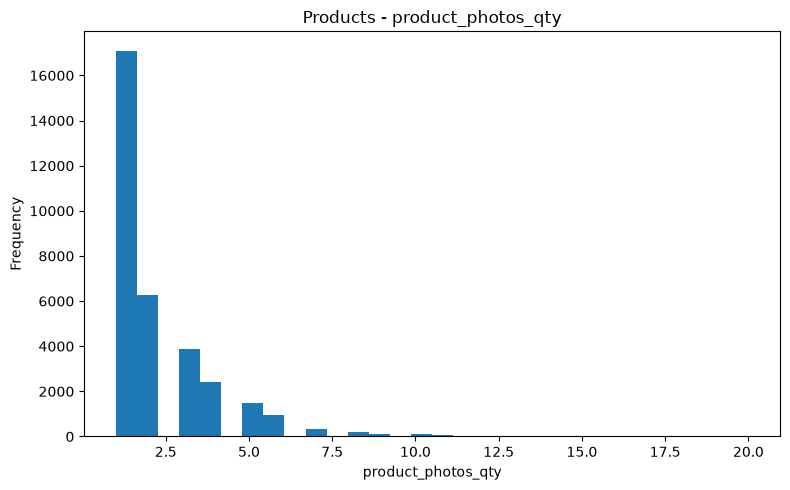

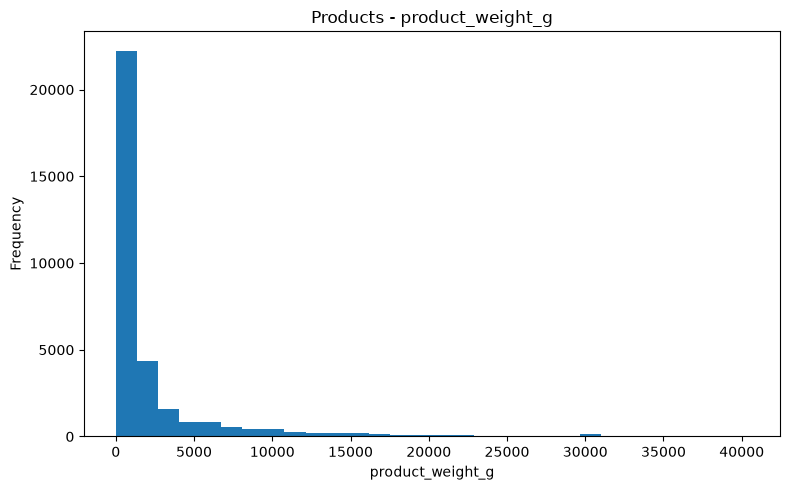

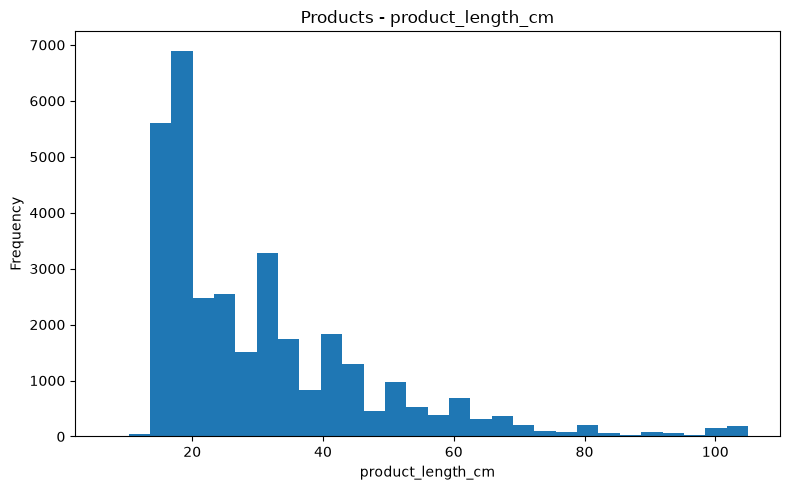

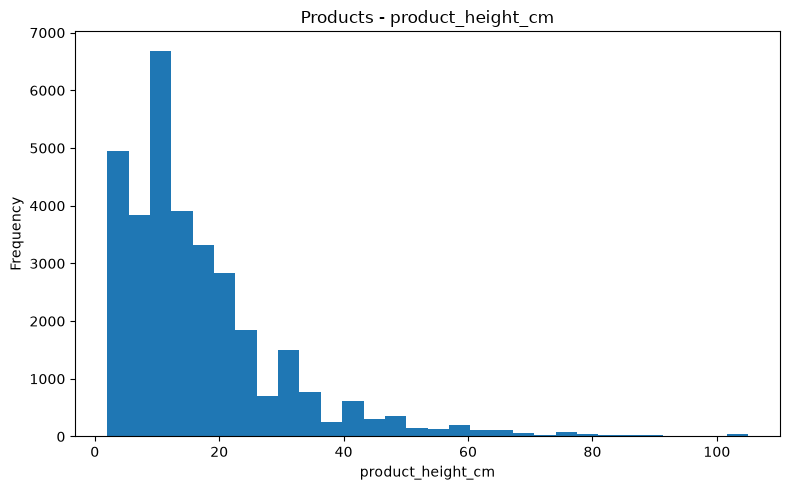

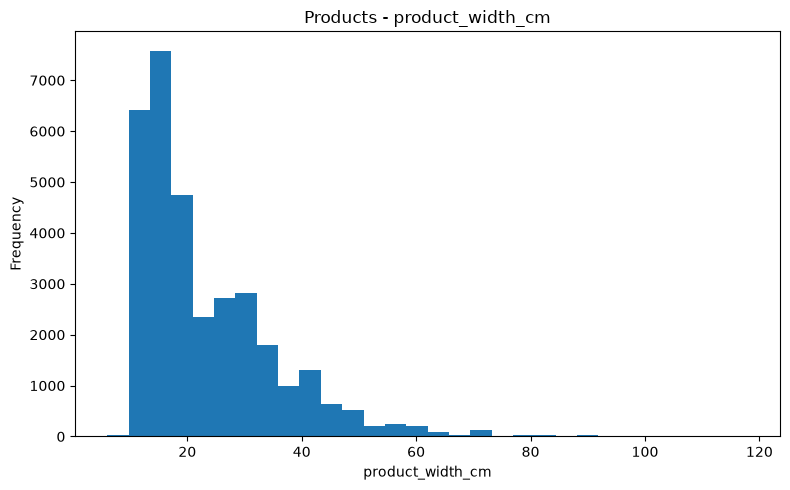

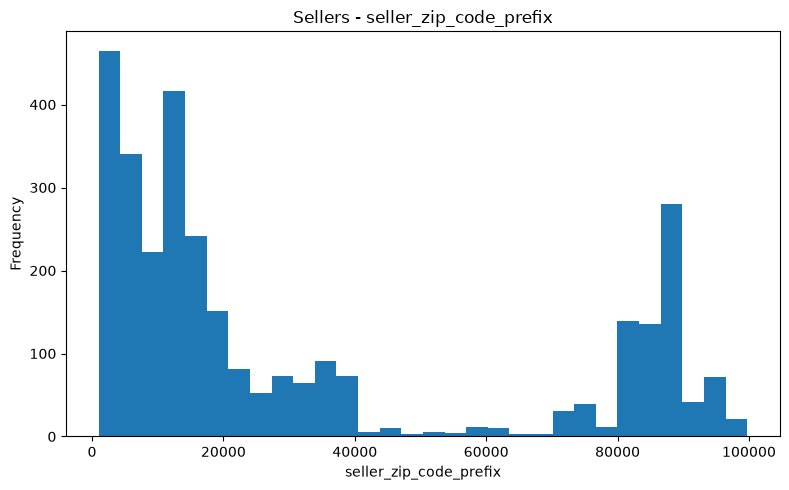

In [117]:
import matplotlib.pyplot as plt

for name, data in datasets.items():

    numerical_cols = data.select_dtypes(include='number').columns

    for col in numerical_cols:

        plt.figure(figsize=(8, 5))

        plt.hist(
            data[col].dropna(),
            bins=30
        )

        plt.title(f"{name} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

In [ ]:
3️⃣ Box Plots

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


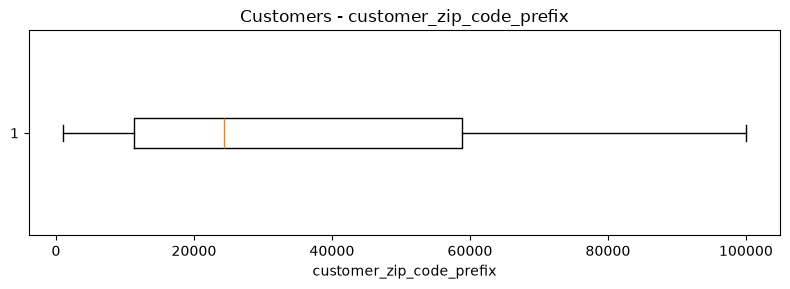

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


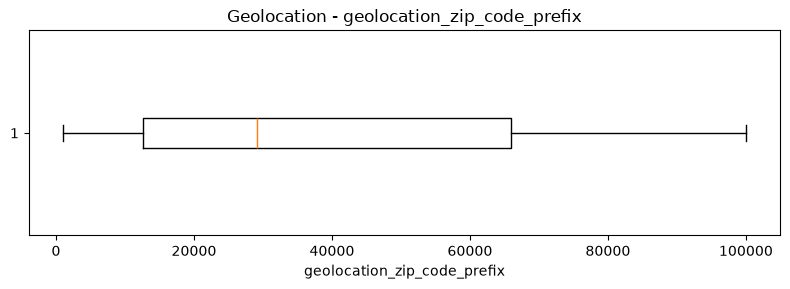

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


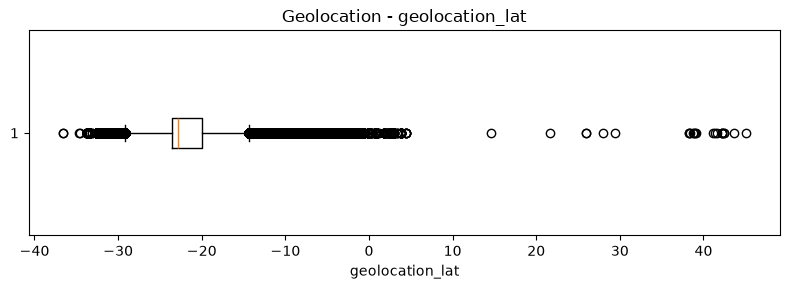

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


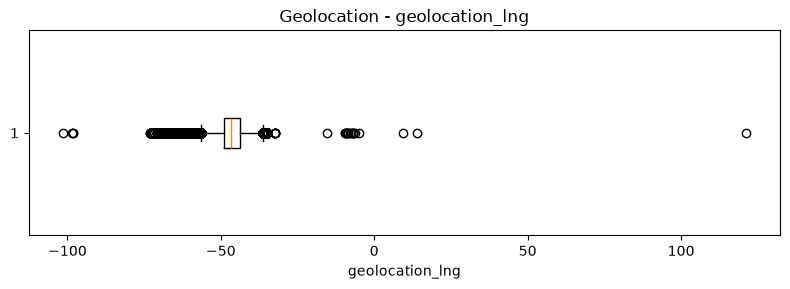

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


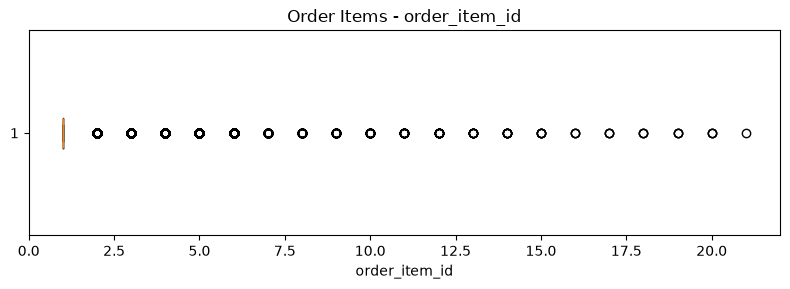

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


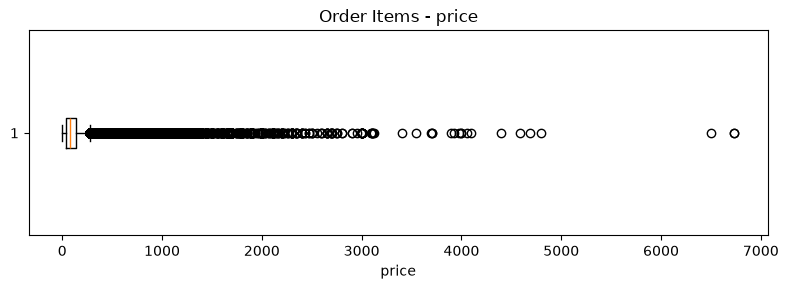

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


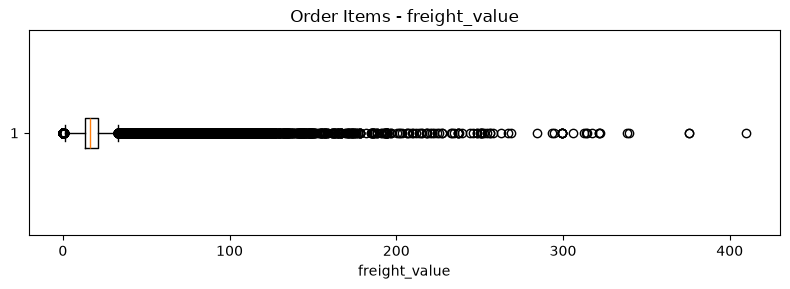

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


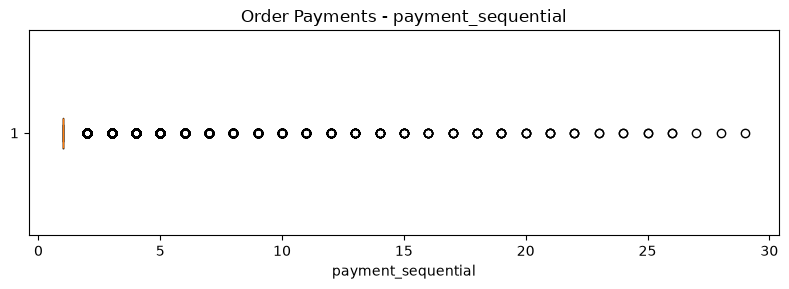

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


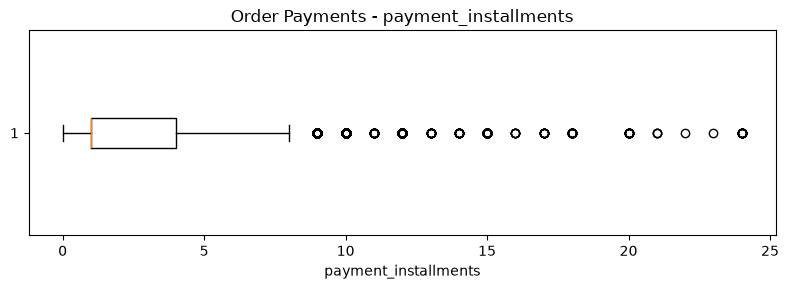

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


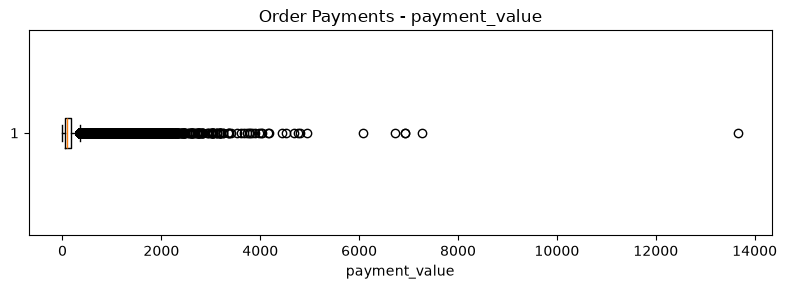

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


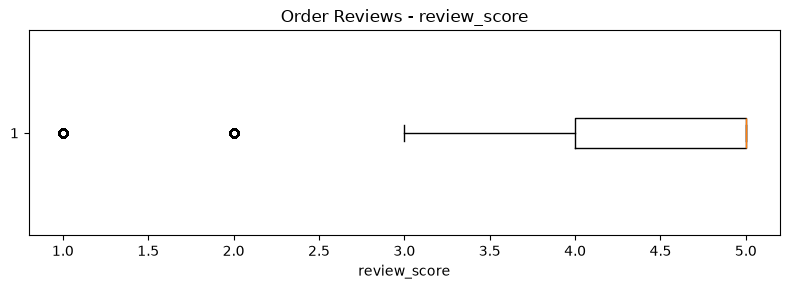

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


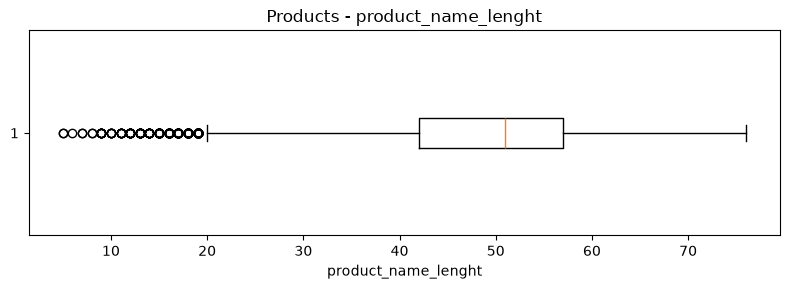

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


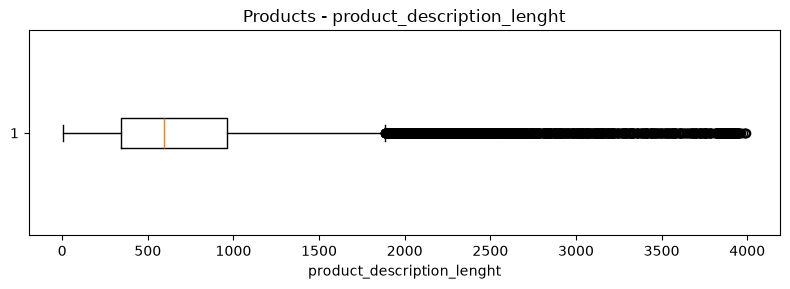

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


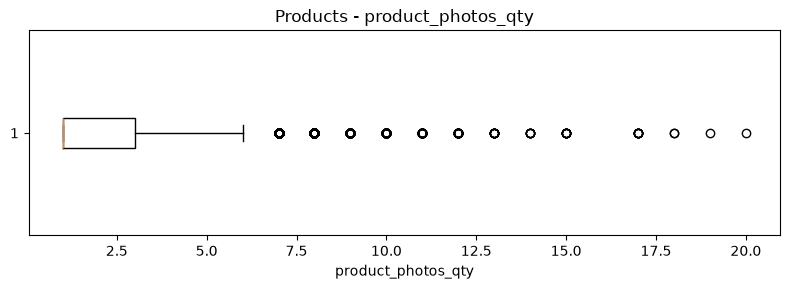

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


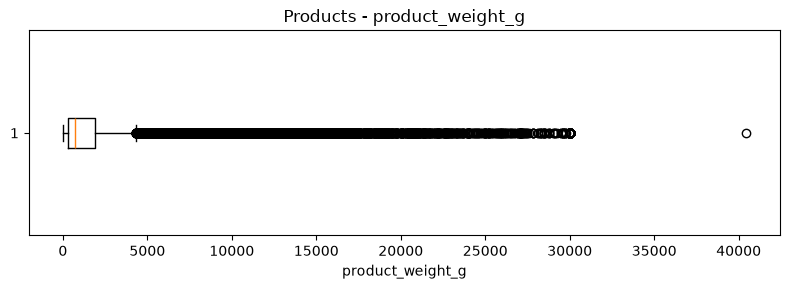

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


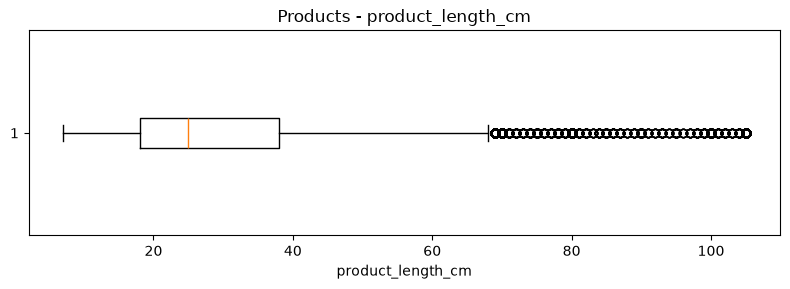

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


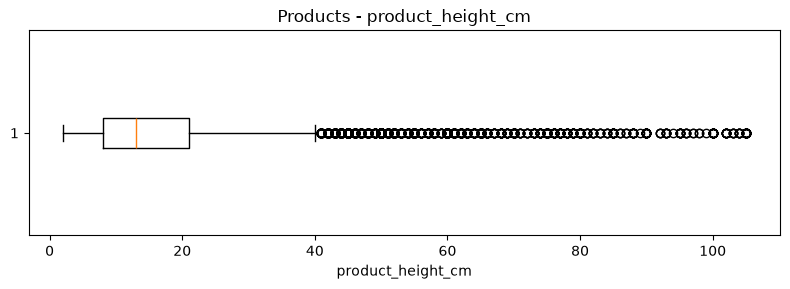

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


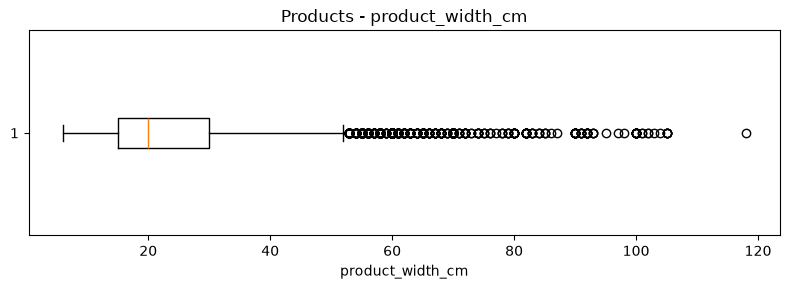

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\1092766922.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


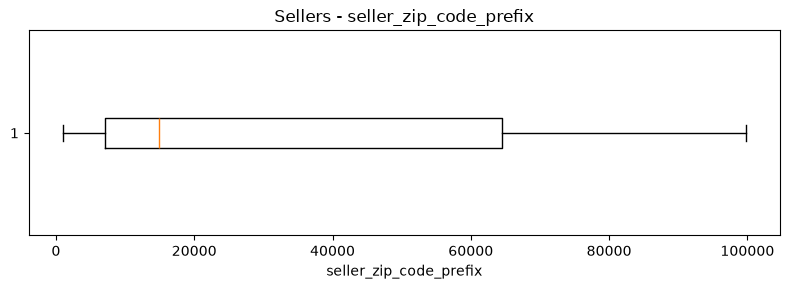

In [118]:
import matplotlib.pyplot as plt

for name, data in datasets.items():

    numerical_cols = data.select_dtypes(include='number').columns

    for col in numerical_cols:

        plt.figure(figsize=(8, 3))

        plt.boxplot(
            data[col].dropna(),
            vert=False
        )

        plt.title(f"{name} - {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

In [ ]:
4️⃣ Categorical Data Analysis

In [119]:
for name, data in datasets.items():

    print("\n" + "=" * 80)
    print(f"UNIVARIATE CATEGORICAL ANALYSIS — {name}")
    print("=" * 80)

    categorical_cols = data.select_dtypes(
        include=['object', 'category']
    ).columns

    if len(categorical_cols) == 0:
        print("No categorical columns")
        continue

    for col in categorical_cols:

        print(f"\n--- {col} ---")
        print(data[col].value_counts(dropna=False))


UNIVARIATE CATEGORICAL ANALYSIS — Customers

--- customer_id ---
customer_id
06b8999e2fba1a1fbc88172c00ba8bc7    1
18955e83d337fd6b2def6b18a428ac77    1
4e7b3e00288586ebd08712fdd0374a03    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
                                   ..
17ddf5dd5d51696bb3d7c6291687be6f    1
e7b71a9017aa05c9a7fd292d714858e8    1
5e28dfe12db7fb50a4b2f691faecea5e    1
56b18e2166679b8a959d72dd06da27f9    1
274fa6071e5e17fe303b9748641082c8    1
Name: count, Length: 99441, dtype: int64

--- customer_unique_id ---
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2406082850.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2406082850.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
                                    ..
0406037ad97740d563a178ecc7a2075c     1
7b905861d7c825891d6347454ea7863f     1
32609bbb3dd69b3c066a6860554a77bf     1
b8b61059626efa996a60be9bb9320e10     1
28bbae6599b09d39ca406b747b6632b1     1
Name: count, Length: 99440, dtype: int64

--- payment_type ---
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

UNIVARIATE CATEGORICAL ANALYSIS — Order Reviews

--- review_id ---
review_id
c444278834184f72b1484dfe47de7f97    3
308316408775d1600dad81bd3184556d    3
2d6ac45f859465b5c185274a1c929637    3
3415c9f764e478409e8e0660ae816dd2    3
4219a80ab469e3fc9901437b73da3f75    3
                                   ..
574ed12dd733e5fa530cfd4bbf39d7c9    1
f3897127253

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2406082850.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\2406082850.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

In [ ]:
5️⃣ Bar Plots for Categorical Variables

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(


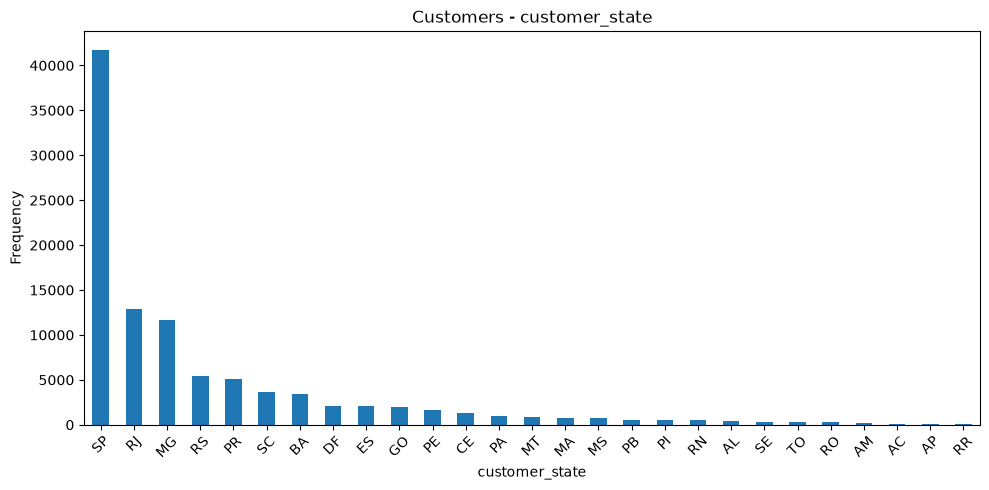

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(


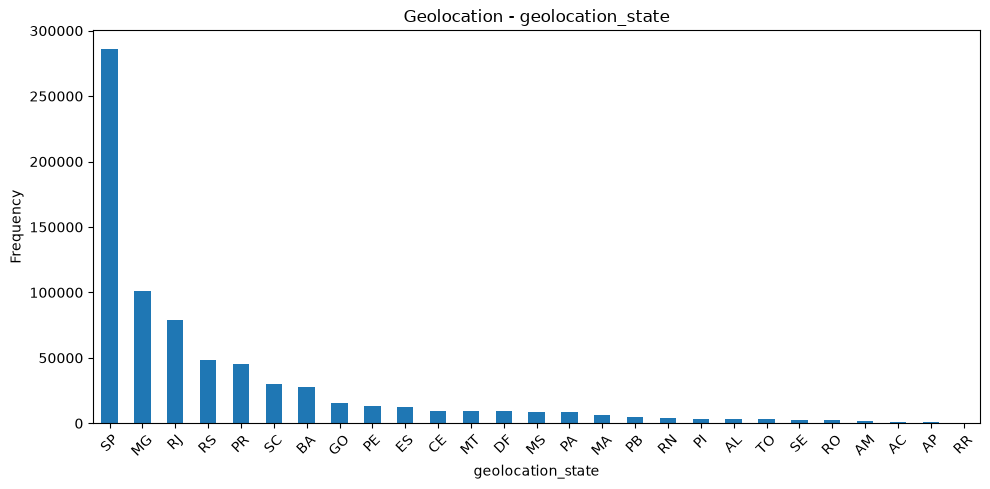

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

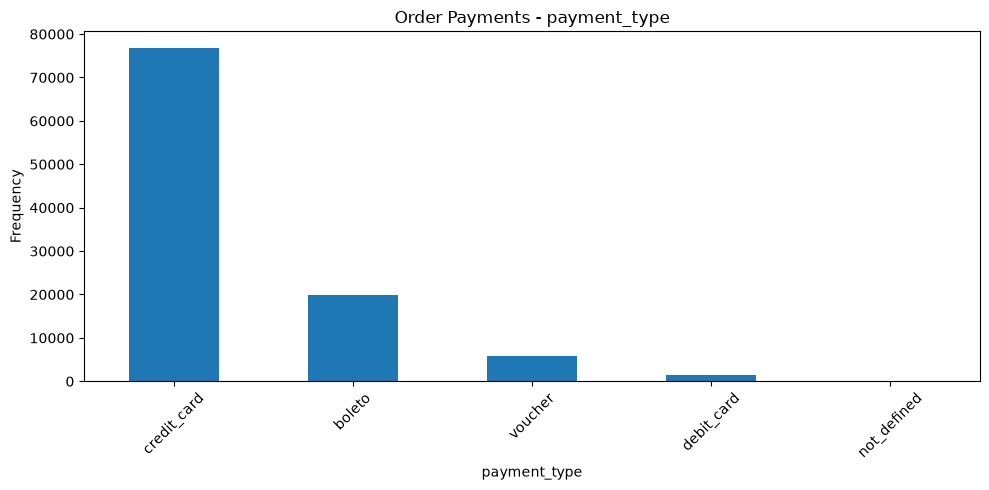

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

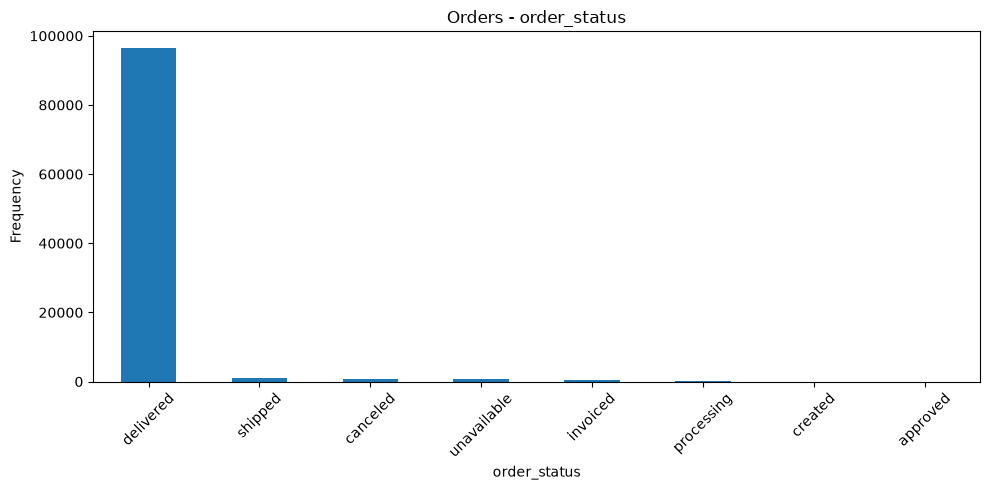

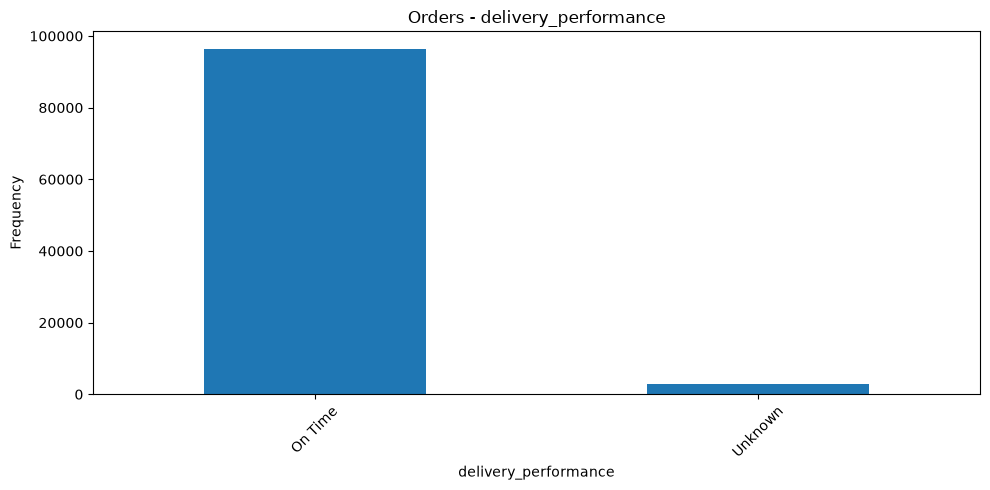

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

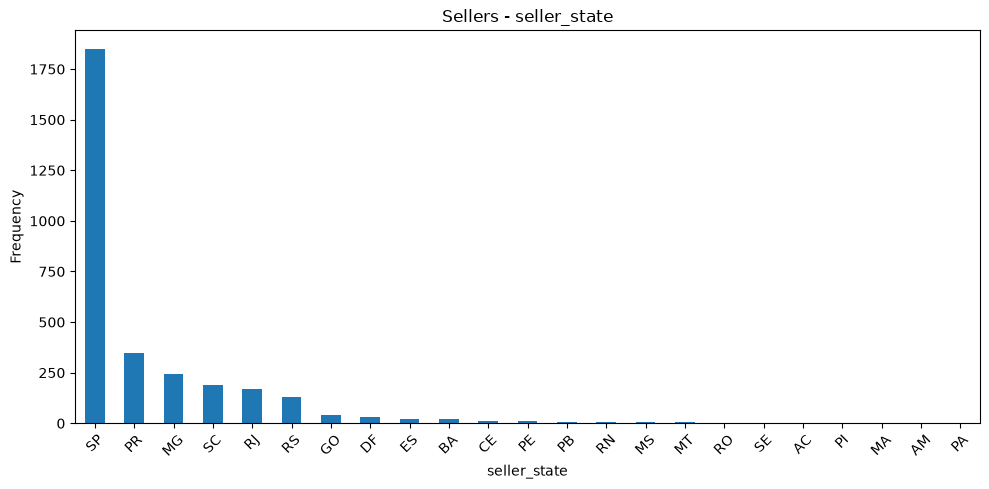

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\3618874342.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(


In [121]:
import matplotlib.pyplot as plt

for name, data in datasets.items():

    categorical_cols = data.select_dtypes(
        include=['object', 'category']
    ).columns

    for col in categorical_cols:

        # Avoid extremely high-cardinality columns
        if data[col].nunique() > 30:
            continue

        plt.figure(figsize=(10, 5))

        data[col].value_counts().plot(
            kind='bar'
        )

        plt.title(f"{name} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
6️⃣ Pie Charts

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

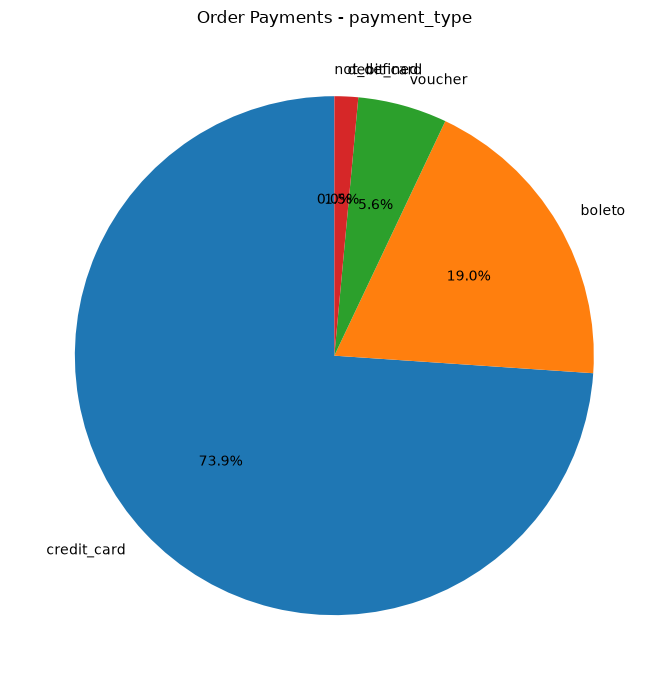

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

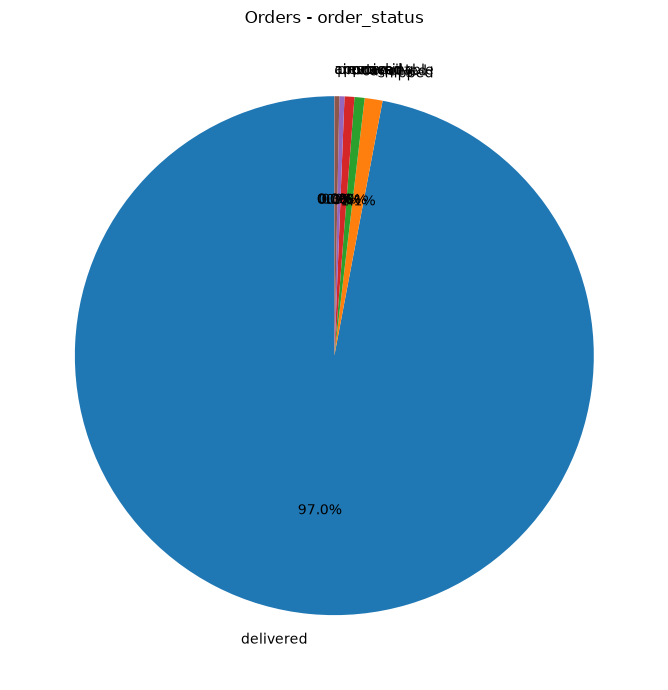

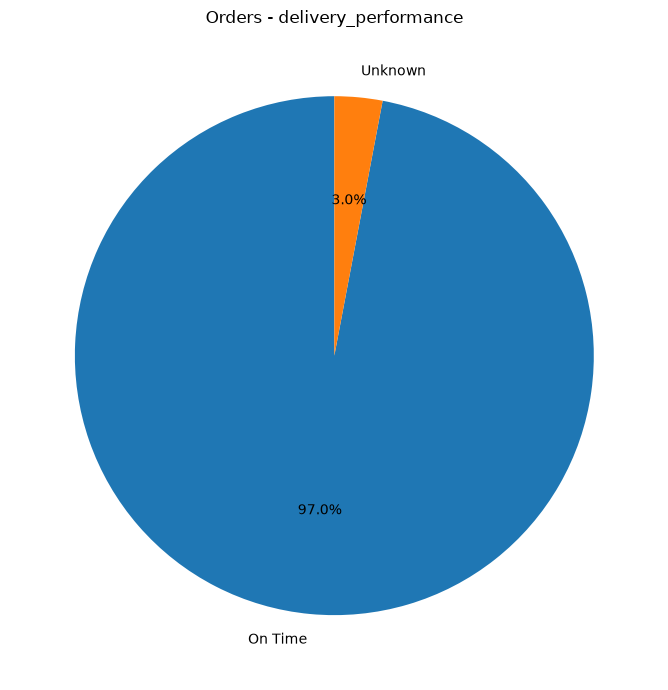

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(
C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_19504\499814587.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

In [122]:
for name, data in datasets.items():

    categorical_cols = data.select_dtypes(
        include=['object', 'category']
    ).columns

    for col in categorical_cols:

        if data[col].nunique() > 10:
            continue

        plt.figure(figsize=(7, 7))

        data[col].value_counts().plot.pie(
            autopct='%1.1f%%',
            startangle=90
        )

        plt.title(f"{name} - {col}")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

In [ ]:
Univariate Analysis: Univariate analysis was performed on individual numerical and categorical variables to understand their distributions, central tendency, variability, category frequencies, skewness, kurtosis, and potential outliers. Numerical variables were analyzed using descriptive statistics, histograms, box plots, skewness, kurtosis, and the IQR method for outlier detection. Categorical variables were analyzed using frequency counts, bar charts, and pie charts where appropriate. High-cardinality identifier columns were excluded from categorical visualizations to avoid uninformative plots.

6. Bivariate Analysis

In [ ]:
ivariate Analysis
Bivariate analysis examines the relationship between two variables to identify patterns, correlations, and dependencies.
It helps answer:
 ✅ How does one variable affect another?
 ✅ Is there a correlation between variables?
 ✅ Are categories related in any way?
Bivariate analysis helps in understanding how two variables are related, leading to better insights & feature selection in data science projects! 


In [ ]:
1️⃣ Numerical vs Numerical

In [123]:
import pandas as pd

for name, data in datasets.items():

    numerical_data = data.select_dtypes(include='number')

    print("\n" + "=" * 80)
    print(f"CORRELATION MATRIX — {name}")
    print("=" * 80)

    if numerical_data.shape[1] < 2:
        print("Not enough numerical columns")
        continue

    print(numerical_data.corr().round(2))


CORRELATION MATRIX — Customers
Not enough numerical columns

CORRELATION MATRIX — Geolocation
                             geolocation_zip_code_prefix  geolocation_lat  \
geolocation_zip_code_prefix                         1.00             0.08   
geolocation_lat                                     0.08             1.00   
geolocation_lng                                    -0.35             0.41   

                             geolocation_lng  
geolocation_zip_code_prefix            -0.35  
geolocation_lat                         0.41  
geolocation_lng                         1.00  

CORRELATION MATRIX — Order Items
               order_item_id  price  freight_value
order_item_id           1.00  -0.06          -0.03
price                  -0.06   1.00           0.41
freight_value          -0.03   0.41           1.00

CORRELATION MATRIX — Order Payments
                      payment_sequential  payment_installments  payment_value
payment_sequential                  1.00               

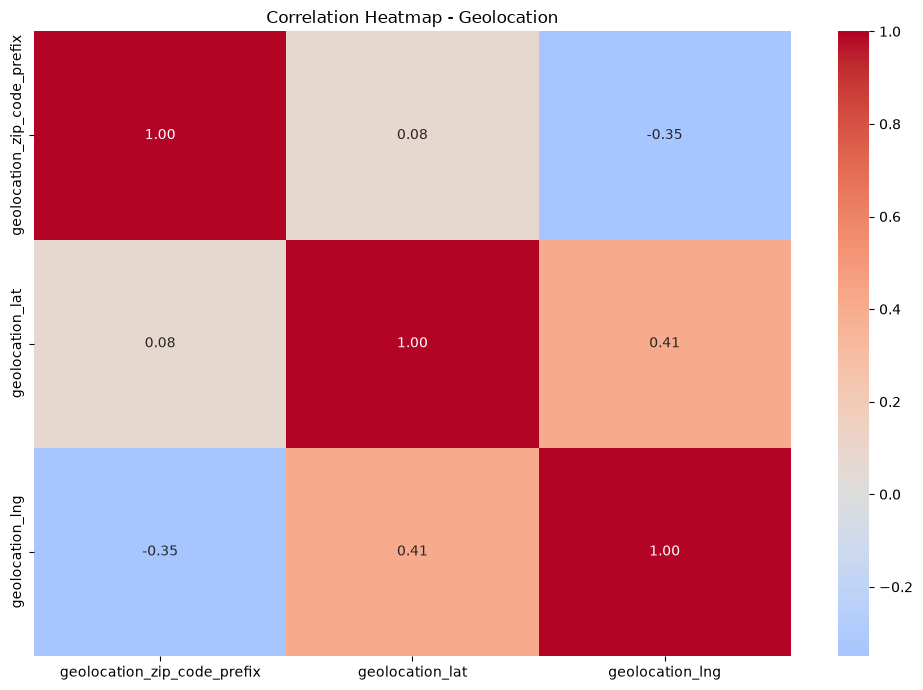

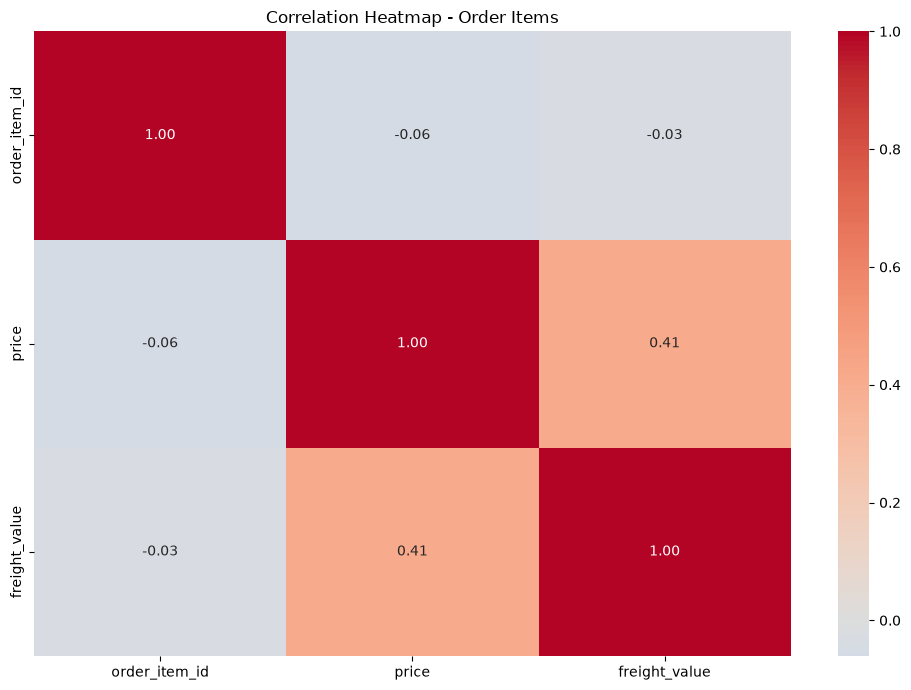

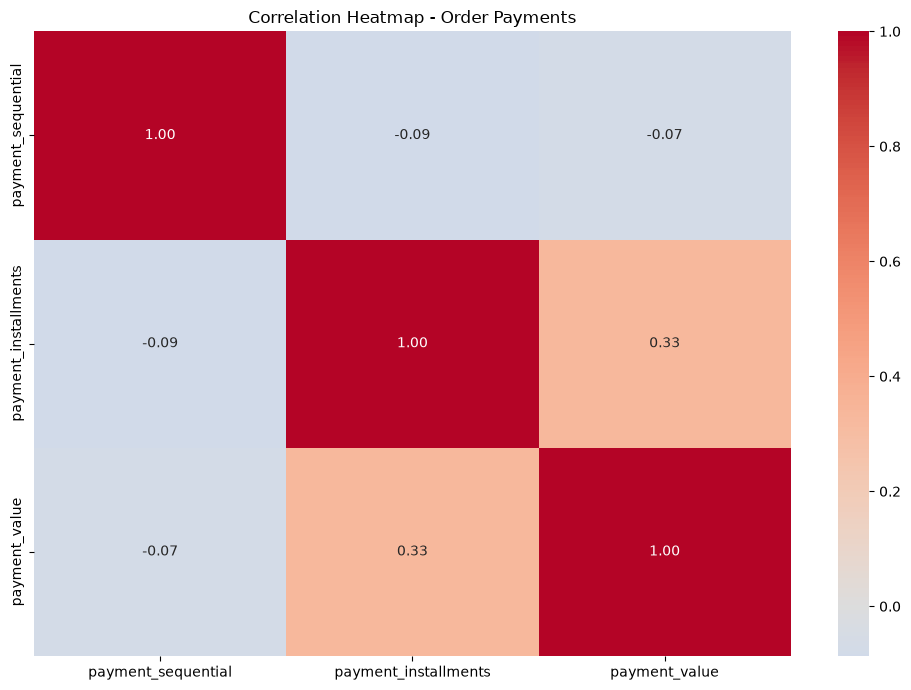

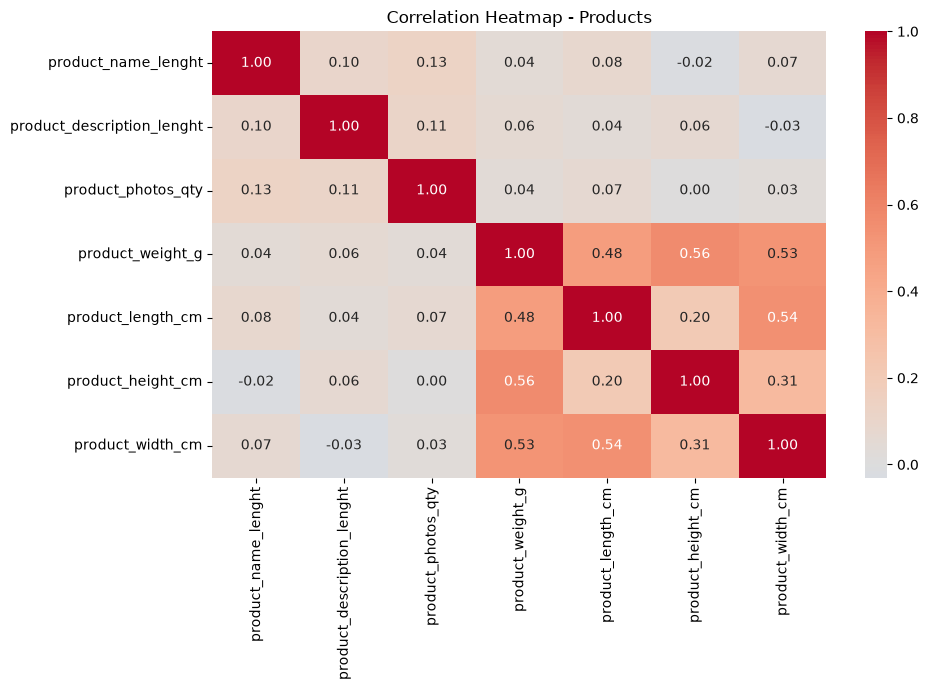

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, data in datasets.items():

    numerical_data = data.select_dtypes(include='number')

    if numerical_data.shape[1] < 2:
        continue

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        numerical_data.corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
2️⃣ Scatter Plot

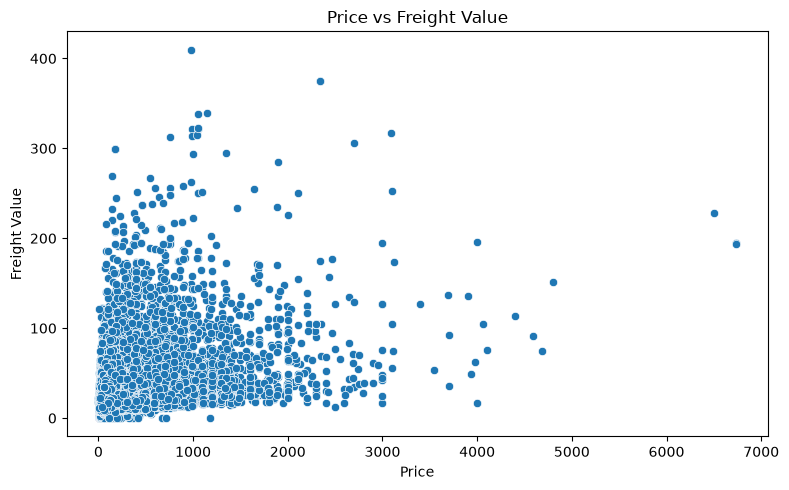

In [125]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=order_items_df,
    x='price',
    y='freight_value'
)

plt.title("Price vs Freight Value")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.tight_layout()
plt.show()

In [ ]:
3️⃣ Regression Plot

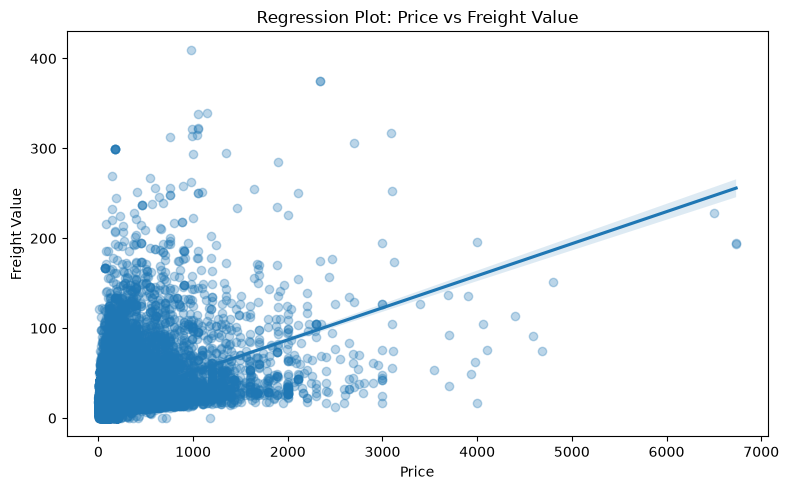

In [126]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=order_items_df,
    x='price',
    y='freight_value',
    scatter_kws={'alpha': 0.3}
)

plt.title("Regression Plot: Price vs Freight Value")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.tight_layout()
plt.show()

In [ ]:
2️⃣ Categorical vs Numerical

In [ ]:
A. Box Plot

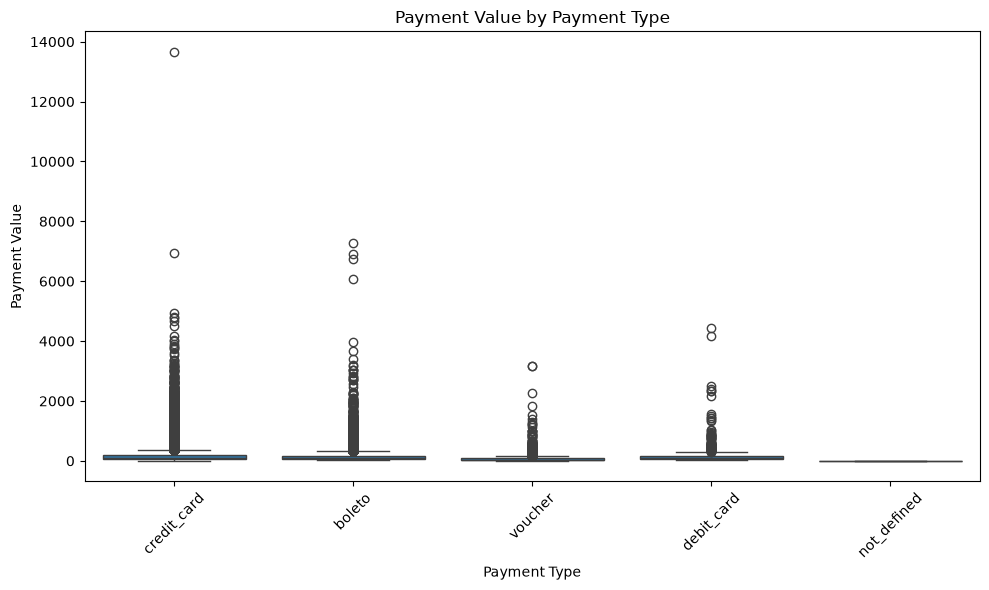

In [127]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=order_payments_df,
    x='payment_type',
    y='payment_value'
)

plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
B. Violin Plot

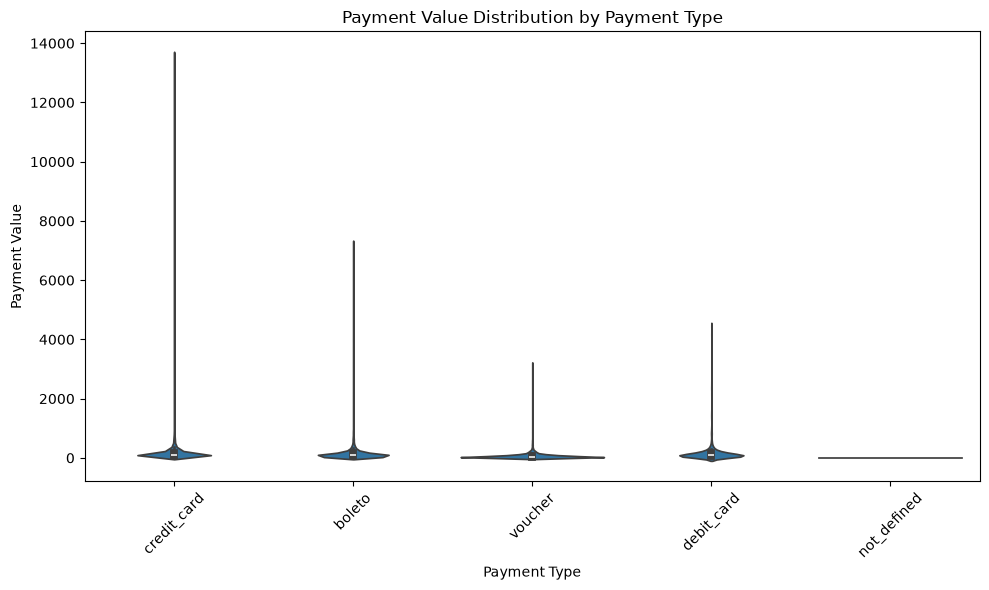

In [128]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=order_payments_df,
    x='payment_type',
    y='payment_value'
)

plt.title("Payment Value Distribution by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
C. Bar Plot — Mean by Category

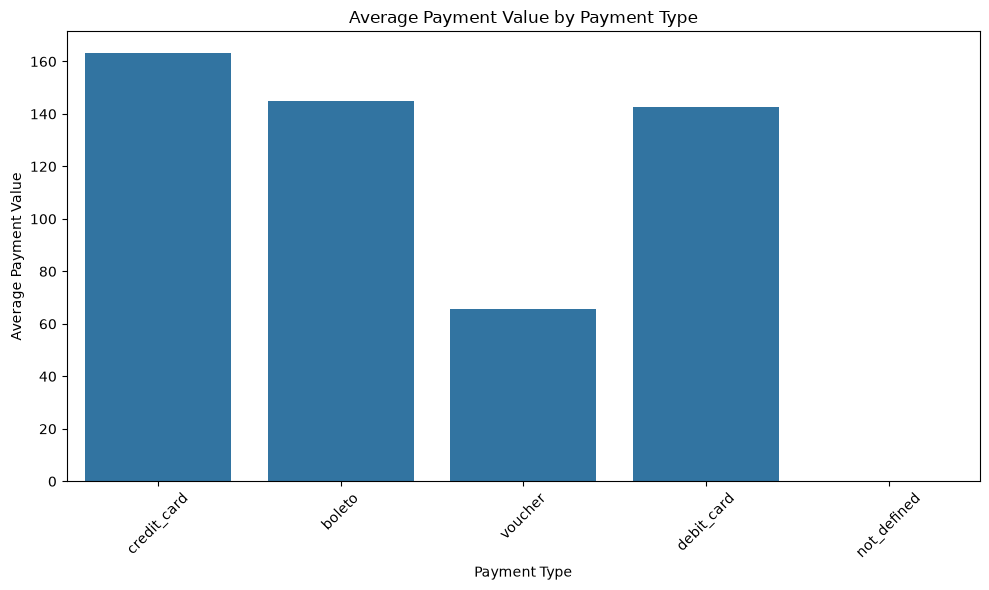

In [129]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=order_payments_df,
    x='payment_type',
    y='payment_value',
    estimator='mean',
    errorbar=None
)

plt.title("Average Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
3️⃣ Categorical vs Categorical

In [ ]:
A. Crosstab

In [130]:
# Merge orders and payments
order_payment_analysis = orders_df[
    ['order_id', 'order_status']
].merge(
    order_payments_df[
        ['order_id', 'payment_type']
    ],
    on='order_id',
    how='inner'
)

crosstab_result = pd.crosstab(
    order_payment_analysis['order_status'],
    order_payment_analysis['payment_type']
)

print(crosstab_result)

payment_type  boleto  credit_card  debit_card  not_defined  voucher
order_status                                                       
approved           0            2           0            0        0
canceled          95          444           7            3      115
created            2            3           0            0        0
delivered      19191        74586        1486            0     5493
invoiced          67          239           6            0       13
processing        70          224           2            0       23
shipped          209          851          22            0       84
unavailable      150          446           6            0       47


In [131]:
crosstab_percentage = pd.crosstab(
    order_payment_analysis['order_status'],
    order_payment_analysis['payment_type'],
    normalize='index'
) * 100

print(crosstab_percentage.round(2))

payment_type  boleto  credit_card  debit_card  not_defined  voucher
order_status                                                       
approved        0.00       100.00        0.00         0.00     0.00
canceled       14.31        66.87        1.05         0.45    17.32
created        40.00        60.00        0.00         0.00     0.00
delivered      19.05        74.03        1.47         0.00     5.45
invoiced       20.62        73.54        1.85         0.00     4.00
processing     21.94        70.22        0.63         0.00     7.21
shipped        17.92        72.98        1.89         0.00     7.20
unavailable    23.11        68.72        0.92         0.00     7.24


In [ ]:
B. Grouped Bar Plot

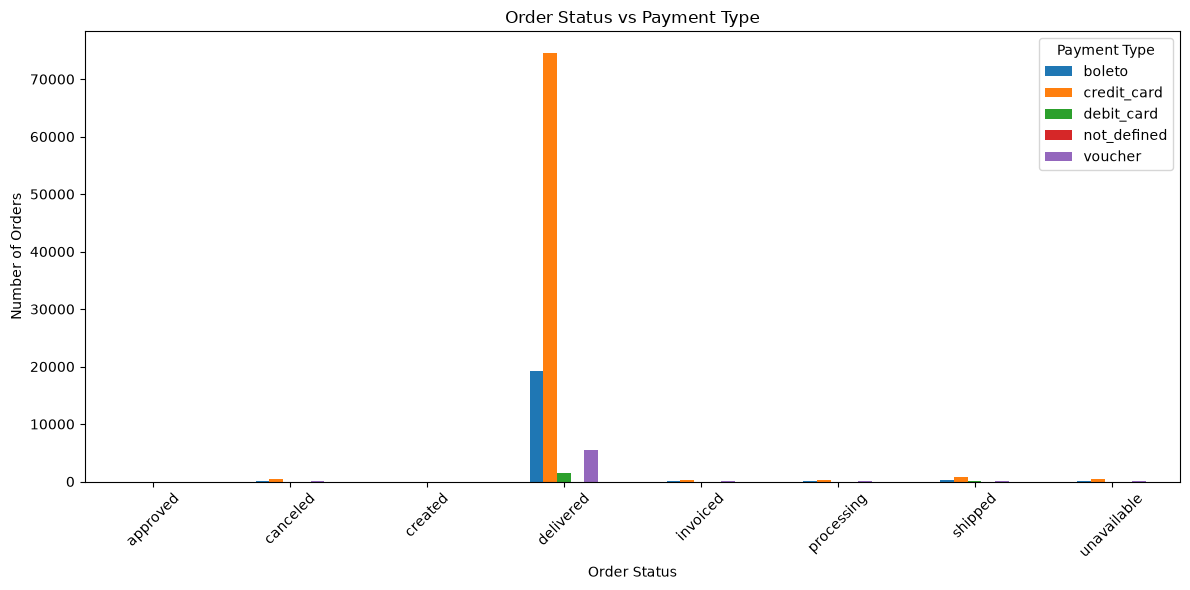

In [132]:
crosstab_result.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Order Status vs Payment Type")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Payment Type")
plt.tight_layout()
plt.show()

In [ ]:
C. Chi-Square Test

In [133]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    crosstab_result
)

print("Chi-Square Statistic :", chi2)
print("p-value              :", p_value)
print("Degrees of Freedom   :", dof)

Chi-Square Statistic : 677.0831369637666
p-value              : 1.2047397488650834e-124
Degrees of Freedom   : 28


In [134]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant association")
else:
    print("No statistically significant association")

Statistically significant association


In [ ]:
Recommended Bivariate Analysis for Your Olist Project
| Variable Type             | Olist Example                             |
| ------------------------- | ----------------------------------------- |
| Numerical ↔ Numerical     | `price` vs `freight_value`                |
| Numerical ↔ Numerical     | `product_weight_g` vs `price`             |
| Numerical ↔ Numerical     | `product_length_cm` vs `product_weight_g` |
| Categorical ↔ Numerical   | `payment_type` vs `payment_value`         |
| Categorical ↔ Numerical   | `review_score` vs `payment_value`         |
| Categorical ↔ Numerical   | `order_status` vs delivery days           |
| Categorical ↔ Categorical | `order_status` vs `payment_type`          |
| Categorical ↔ Categorical | `review_score` vs `order_status`          |


In [ ]:
Bivariate Analysis: Bivariate analysis was performed to investigate relationships between pairs of variables. Numerical variables were analyzed using correlation matrices, heatmaps, scatter plots, and regression plots. Categorical and numerical variables were compared using box plots, violin plots, and mean-based bar plots. Relationships between categorical variables were examined using contingency tables, grouped bar charts, and the Chi-square test of independence. These analyses helped identify associations, distributional differences, and potentially useful relationships for subsequent analytical and machine-learning tasks.

In [ ]:
7. Detecting Outliers


In [ ]:
What is an Outlier?
An outlier is a data point that deviates significantly from the rest of the data.


It can be due to errors, natural variability, or rare events.
Why Detect Outliers?
✔ Prevents skewed statistical analysis.
 ✔ Improves model accuracy.
 ✔ Identifies data quality issues or anomalies.


In [ ]:
1️⃣ IQR Method — Main Method

In [135]:
import pandas as pd
import numpy as np

outlier_summary = []

for name, data in datasets.items():

    numerical_cols = data.select_dtypes(
        include='number'
    ).columns

    for col in numerical_cols:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_mask = (
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        )

        outlier_count = outlier_mask.sum()
        total_count = data[col].notna().sum()

        outlier_percentage = (
            outlier_count / total_count * 100
            if total_count > 0 else 0
        )

        outlier_summary.append({
            'Dataset': name,
            'Column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_percentage
        })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df)

           Dataset                       Column            Q1            Q3  \
0        Customers     customer_zip_code_prefix  11347.000000  58900.000000   
1      Geolocation  geolocation_zip_code_prefix  12600.000000  65950.000000   
2      Geolocation              geolocation_lat    -23.603061    -19.923332   
3      Geolocation              geolocation_lng    -48.867871    -43.836979   
4      Order Items                order_item_id      1.000000      1.000000   
5      Order Items                        price     39.900000    134.900000   
6      Order Items                freight_value     13.080000     21.150000   
7   Order Payments           payment_sequential      1.000000      1.000000   
8   Order Payments         payment_installments      1.000000      4.000000   
9   Order Payments                payment_value     56.790000    171.837500   
10   Order Reviews                 review_score      4.000000      5.000000   
11        Products          product_name_lenght     

In [136]:
outlier_df[outlier_df['Outlier_Count'] > 0]

,Dataset,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
2,Geolocation,geolocation_lat,-23.603061,-19.923332,3.679729,-29.122655,-14.403738,130286,17.646111
3,Geolocation,geolocation_lng,-48.867871,-43.836979,5.030892,-56.414209,-36.290641,28738,3.892313
4,Order Items,order_item_id,1.000000,1.000000,0.000000,1.000000,1.000000,13984,12.413671
5,Order Items,price,39.900000,134.900000,95.000000,-102.600000,277.400000,8427,7.480692
6,Order Items,freight_value,13.080000,21.150000,8.070000,0.975000,33.255000,12134,10.771416
7,Order Payments,payment_sequential,1.000000,1.000000,0.000000,1.000000,1.000000,4526,4.356699
8,Order Payments,payment_installments,1.000000,4.000000,3.000000,-3.500000,8.500000,6313,6.076853
9,Order Payments,payment_value,56.790000,171.837500,115.047500,-115.781250,344.408750,7981,7.682460
10,Order Reviews,review_score,4.000000,5.000000,1.000000,2.500000,6.500000,14575,14.688987
11,Products,product_name_lenght,42.000000,57.000000,15.000000,19.500000,79.500000,290,0.880095


In [ ]:
2️⃣ Display the Actual Outlier Records

In [137]:
Q1 = order_items_df['price'].quantile(0.25)
Q3 = order_items_df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = order_items_df[
    (order_items_df['price'] < lower_bound) |
    (order_items_df['price'] > upper_bound)
]

print(price_outliers)

                                order_id  order_item_id  \
7       000576fe39319847cbb9d288c5617fa6              1   
16      0009c9a17f916a706d71784483a5d643              1   
26      0011d82c4b53e22e84023405fb467e57              1   
30      00137e170939bba5a3134e2386413108              1   
39      0017afd5076e074a48f1f1a4c7bac9c5              1   
...                                  ...            ...   
112586  ffdc5e3279114c523a09296f8fd28331              1   
112592  ffde92ba447b33a47d1c04d203f10f41              1   
112632  fff7c4452f050315db1b3f24d9df5fcd              1   
112645  fffc94f6ce00a00581880bf54a75a037              1   
112646  fffcd46ef2263f404302a634eb57f7eb              1   

                              product_id                         seller_id  \
7       557d850972a7d6f792fd18ae1400d9b6  5996cddab893a4652a15592fb58ab8db   
16      3f27ac8e699df3d300ec4a5d8c5cf0b2  fcb5ace8bcc92f75707dc0f01a27d269   
26      c389f712c4b4510bc997cee93e8b1a28  bfd27a966d91cfa

In [138]:
order_items_df[
    ['order_id', 'product_id', 'price']
].sort_values(
    by='price',
    ascending=False
).head(20)

,order_id,product_id,price
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90


In [ ]:
3️⃣ Box Plot

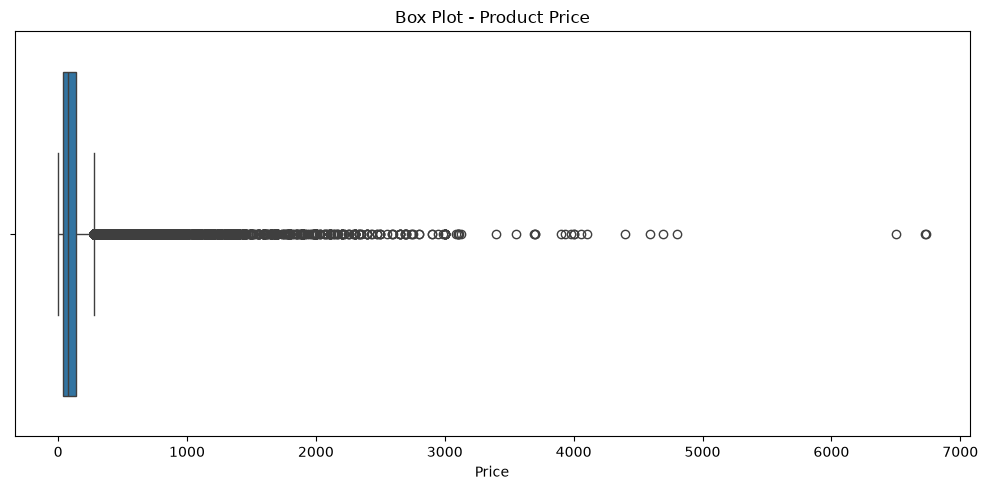

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=order_items_df['price']
)

plt.title("Box Plot - Product Price")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

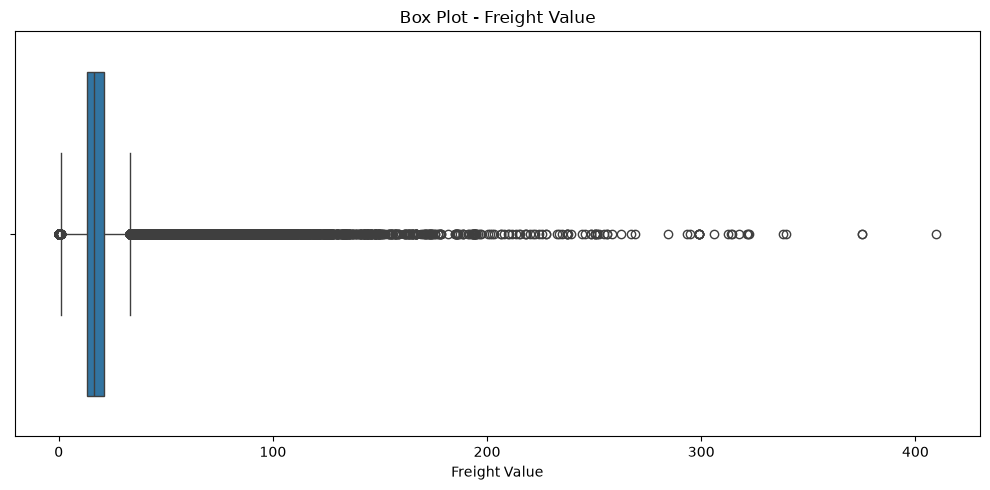

In [140]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=order_items_df['freight_value']
)

plt.title("Box Plot - Freight Value")
plt.xlabel("Freight Value")
plt.tight_layout()
plt.show()

In [ ]:
4️⃣ Histogram + KDE

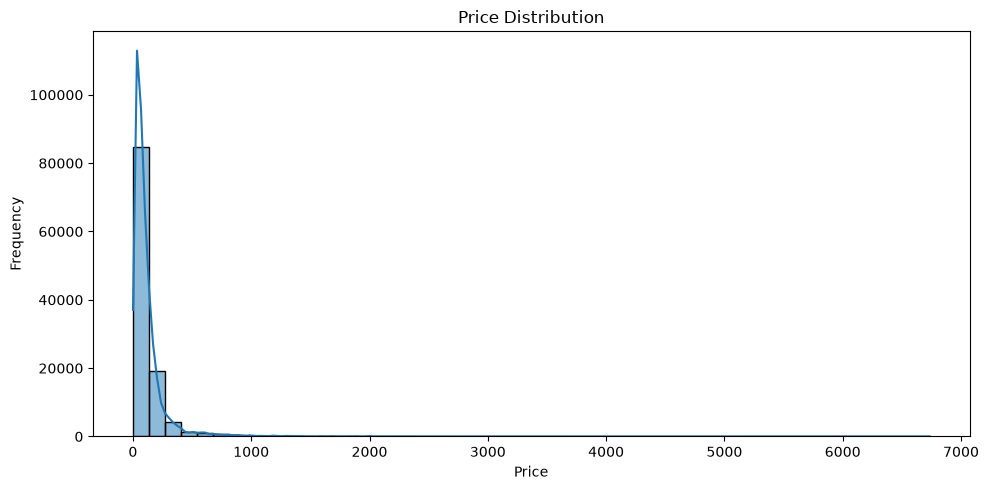

In [141]:
plt.figure(figsize=(10, 5))

sns.histplot(
    order_items_df['price'].dropna(),
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
5️⃣ Z-Score Method

In [142]:
from scipy.stats import zscore

price_data = order_items_df[
    ['price']
].dropna().copy()

price_data['z_score'] = zscore(
    price_data['price']
)

zscore_outliers = price_data[
    price_data['z_score'].abs() > 3
]

print(zscore_outliers)
print("Number of Z-score outliers:",
      len(zscore_outliers))

          price   z_score
7        810.00  3.753932
39       809.10  3.749031
322     1050.61  5.064208
344      849.00  3.966312
475      899.00  4.238594
...         ...       ...
112324   935.00  4.434637
112343   699.00  3.149466
112449   899.00  4.238594
112557   765.00  3.508878
112632   736.00  3.350955

[1966 rows x 2 columns]
Number of Z-score outliers: 1966


In [ ]:
6️⃣ Isolation Forest

In [143]:
from sklearn.ensemble import IsolationForest

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

product_model_data = products_df[features].dropna().copy()

model = IsolationForest(
    contamination='auto',
    random_state=42
)

product_model_data['anomaly'] = model.fit_predict(
    product_model_data[features]
)

print(
    product_model_data['anomaly'].value_counts()
)

anomaly
 1    27457
-1     5494
Name: count, dtype: int64


In [144]:
anomalies = product_model_data[
    product_model_data['anomaly'] == -1
]

print(anomalies)

       product_weight_g  product_length_cm  product_height_cm  \
0               16400.0               63.0               66.0   
1                1050.0               38.0               41.0   
7                5047.0               58.0               44.0   
9               12800.0               67.0               57.0   
11              10650.0               26.0               80.0   
...                 ...                ...                ...   
32918            8500.0               23.0               16.0   
32919           26950.0               65.0               79.0   
32926           16550.0               58.0               32.0   
32946            1800.0               30.0               20.0   
32950             700.0               28.0                3.0   

       product_width_cm  anomaly  
0                  56.0       -1  
1                  39.0       -1  
7                  28.0       -1  
9                  30.0       -1  
11                 26.0       -1  
...      

In [ ]:
7️⃣ DBSCAN

In [145]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

dbscan_data = products_df[
    features
].dropna().copy()

scaled_data = StandardScaler().fit_transform(
    dbscan_data
)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    scaled_data
)

dbscan_data['cluster'] = dbscan_labels

print(dbscan_data['cluster'].value_counts())

cluster
 0     32507
-1       328
 7        16
 2        13
 1        11
 11       11
 8        10
 9        10
 6         9
 4         8
 5         7
 10        6
 3         5
 12        5
 13        5
Name: count, dtype: int64


In [ ]:
8️⃣ Create a Final Outlier Summary

In [146]:
print(
    outlier_df[
        [
            'Dataset',
            'Column',
            'Outlier_Count',
            'Outlier_Percentage'
        ]
    ].sort_values(
        by='Outlier_Percentage',
        ascending=False
    ).to_string(index=False)
)

       Dataset                      Column  Outlier_Count  Outlier_Percentage
   Geolocation             geolocation_lat         130286           17.646111
 Order Reviews                review_score          14575           14.688987
      Products            product_weight_g           4551           13.811417
   Order Items               order_item_id          13984           12.413671
   Order Items               freight_value          12134           10.771416
Order Payments               payment_value           7981            7.682460
   Order Items                       price           8427            7.480692
      Products  product_description_lenght           2174            6.597675
Order Payments        payment_installments           6313            6.076853
      Products           product_height_cm           1892            5.741859
Order Payments          payment_sequential           4526            4.356699
      Products           product_length_cm           1380       

In [ ]:
Outlier Detection: Outliers were identified using visual and statistical techniques. Box plots, histograms, and KDE plots were used for visual inspection. The Interquartile Range (IQR) method was applied as the primary statistical approach, with observations outside the lower and upper IQR boundaries flagged as potential outliers. Z-score analysis was additionally considered for approximately normally distributed variables. Isolation Forest and DBSCAN were evaluated as machine-learning-based approaches for detecting multivariate anomalies. Detected outliers were not automatically removed because extreme values in e-commerce datasets may represent legitimate business observations. Potential anomalies were therefore investigated before deciding on removal, transformation, capping, or retention.

In [ ]:

8. Feature Engineering


Feature engineering is the process of transforming raw data into meaningful features that improve machine learning model performance. It involves creating, modifying, or selecting features to enhance predictive power.

Step                          Techniques
Handling Missing Values
                            Imputation (mean, median, mode), indicator columns
Handling Outliers
                            IQR, Z-score, transformations (log, sqrt)
Feature Creation
                            Time-based, ratio, polynomial features
Encoding Categorical Data
                            Label Encoding, One-Hot Encoding, Target Encoding
Feature Scaling
                            Standardization, Min-Max Scaling, Robust Scaling
Feature Selection
                            Correlation analysis, Low variance filtering, Recursive Feature Elimination
Dimensionality Reduction
                            PCA, t-SNE, UMAP



Raw Data
   ↓
Missing Value Handling
   ↓
Outlier Investigation
   ↓
Date/Time Features
   ↓
Delivery Features
   ↓
Ratio Features
   ↓
Aggregation Features
   ↓
Categorical Encoding
   ↓
Feature Scaling
   ↓
Feature Selection
   ↓
ML-Ready Dataset

In [ ]:
Feature engineering means creating useful variables from existing raw variables so that the data becomes more informative for analysis and machine-learning models.

For  Olist project, I recommend focusing mainly on time-based features, delivery features, price/payment features, and categorical encoding.

In [ ]:
1️⃣ Handling Missing Values

In [147]:
orders_df['delivery_date_missing'] = (
    orders_df['order_delivered_customer_date']
    .isna()
    .astype(int)
)

print(
    orders_df['delivery_date_missing'].value_counts()
)

delivery_date_missing
0    99441
Name: count, dtype: int64


In [148]:
print(
    orders_df['order_delivered_customer_date'].isna().sum()
)

0


In [ ]:
2️⃣ Time-Based Feature Creation

In [173]:
## Step 1 — Run this first
import pandas as pd

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        dayfirst=True,
        errors='coerce'
    )

print(orders_df[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [174]:
## Step 2 — Create the time-based features
orders_df['purchase_year'] = (
    orders_df['order_purchase_timestamp'].dt.year
)

orders_df['purchase_month'] = (
    orders_df['order_purchase_timestamp'].dt.month
)

orders_df['purchase_day'] = (
    orders_df['order_purchase_timestamp'].dt.day
)

orders_df['purchase_dayofweek'] = (
    orders_df['order_purchase_timestamp'].dt.dayofweek
)

orders_df['purchase_hour'] = (
    orders_df['order_purchase_timestamp'].dt.hour
)

orders_df['is_weekend'] = (
    orders_df['purchase_dayofweek'] >= 5
).astype(int)

In [175]:
## Step 3 — Check the result
print(
    orders_df[
        [
            'order_purchase_timestamp',
            'purchase_year',
            'purchase_month',
            'purchase_day',
            'purchase_dayofweek',
            'purchase_hour',
            'is_weekend'
        ]
    ].head(10)
)

  order_purchase_timestamp  purchase_year  purchase_month  purchase_day  \
0      2017-10-02 10:56:00           2017              10             2   
1      2018-07-24 20:41:00           2018               7            24   
2      2018-08-08 08:38:00           2018               8             8   
3      2017-11-18 19:28:00           2017              11            18   
4      2018-02-13 21:18:00           2018               2            13   
5      2017-07-09 21:57:00           2017               7             9   
6      2017-04-11 12:22:00           2017               4            11   
7      2017-05-16 13:10:00           2017               5            16   
8      2017-01-23 18:29:00           2017               1            23   
9      2017-07-29 11:55:00           2017               7            29   

   purchase_dayofweek  purchase_hour  is_weekend  
0                   0             10           0  
1                   1             20           0  
2                   2

In [ ]:
3️⃣ Delivery Features

In [176]:
## Step 1 — Make sure the date columns are datetime
import pandas as pd

date_columns = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col],
        dayfirst=True,
        errors='coerce'
    )

print(orders_df[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [ ]:
## 

In [156]:
## Step 2 — Create Actual Delivery Days 
orders_df['actual_delivery_days'] = (
    orders_df['order_delivered_customer_date']
    - orders_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

In [157]:
## Estimated delivery days
orders_df['estimated_delivery_days'] = (
    orders_df['order_estimated_delivery_date']
    - orders_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

In [158]:
## Delivery delay
orders_df['delivery_delay_days'] = (
    orders_df['actual_delivery_days']
    - orders_df['estimated_delivery_days']
)

In [159]:
## Delivery performance
orders_df['delivery_performance'] = 'Unknown'

mask = (
    orders_df['actual_delivery_days'].notna() &
    orders_df['estimated_delivery_days'].notna()
)

orders_df.loc[mask, 'delivery_performance'] = 'On Time'

orders_df.loc[
    mask &
    (orders_df['delivery_delay_days'] > 0),
    'delivery_performance'
] = 'Delayed'

In [177]:
## Check result
print(
    orders_df[
        [
            'order_id',
            'actual_delivery_days',
            'estimated_delivery_days',
            'delivery_delay_days',
            'delivery_performance'
        ]
    ].head(10)
)

                           order_id  actual_delivery_days  \
0  e481f51cbdc54678b7cc49136f2d6af7              8.436806   
1  53cdb2fc8bc7dce0b6741e2150273451             13.781944   
2  47770eb9100c2d0c44946d9cf07ec65d              9.394444   
3  949d5b44dbf5de918fe9c16f97b45f8a             13.208333   
4  ad21c59c0840e6cb83a9ceb5573f8159              2.874306   
5  a4591c265e18cb1dcee52889e2d8acc3             16.541667   
6  136cce7faa42fdb2cefd53fdc79a6098            105.940972   
7  6514b8ad8028c9f2cc2374ded245783f              9.989583   
8  76c6e866289321a7c93b82b54852dc33              9.818750   
9  e69bfb5eb88e0ed6a785585b27e16dbf             18.221528   

   estimated_delivery_days  delivery_delay_days delivery_performance  
0                15.544444            -7.107639              On Time  
1                19.138194            -5.356250              On Time  
2                26.640278           -17.245833              On Time  
3                26.188889           -12.980

In [178]:
print(orders_df['delivery_performance'].value_counts(dropna=False))

delivery_performance
On Time    89996
Delayed     9445
Name: count, dtype: int64


In [ ]:
4️⃣ Ratio Features

In [160]:
## Freight-to-price ratio
order_items_df['freight_price_ratio'] = (
    order_items_df['freight_value'] /
    order_items_df['price'].replace(0, np.nan)
)

In [161]:
## 
order_items_df[
    [
        'price',
        'freight_value',
        'freight_price_ratio'
    ]
].head()

,price,freight_value,freight_price_ratio
0,58.90,13.29,0.225637
1,239.90,19.93,0.083076
2,199.00,17.87,0.089799
3,12.99,12.79,0.984604
4,199.90,18.14,0.090745


In [ ]:
5️⃣ Aggregate Features

In [162]:
## Number of orders per customer
customer_order_count = (
    orders_df
    .groupby('customer_id')
    .size()
    .reset_index(name='total_orders')
)

print(customer_order_count.head())

                        customer_id  total_orders
0  00012a2ce6f8dcda20d059ce98491703             1
1  000161a058600d5901f007fab4c27140             1
2  0001fd6190edaaf884bcaf3d49edf079             1
3  0002414f95344307404f0ace7a26f1d5             1
4  000379cdec625522490c315e70c7a9fb             1


In [163]:
## Average order delivery time
customer_delivery = (
    orders_df
    .groupby('customer_id')['actual_delivery_days']
    .mean()
    .reset_index(name='avg_delivery_days')
)

print(customer_delivery.head())

                        customer_id  avg_delivery_days
0  00012a2ce6f8dcda20d059ce98491703          13.981250
1  000161a058600d5901f007fab4c27140           9.386806
2  0001fd6190edaaf884bcaf3d49edf079           5.910417
3  0002414f95344307404f0ace7a26f1d5          28.289583
4  000379cdec625522490c315e70c7a9fb          11.277083


In [164]:
## Total spending per order
order_payment_total = (
    order_payments_df
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index(name='total_payment_value')
)

print(order_payment_total.head())

                           order_id  total_payment_value
0  00010242fe8c5a6d1ba2dd792cb16214                72.19
1  00018f77f2f0320c557190d7a144bdd3               259.83
2  000229ec398224ef6ca0657da4fc703e               216.87
3  00024acbcdf0a6daa1e931b038114c75                25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9               218.04


Encoding Categorical Data

In [ ]:
#⃣# Categorical Encoding

In [165]:
## One-Hot Encoding
payment_encoded = pd.get_dummies(
    order_payments_df,
    columns=['payment_type'],
    dtype=int
)

print(payment_encoded.head())

                           order_id  payment_sequential  payment_installments  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1                     8   
1  a9810da82917af2d9aefd1278f1dcfa0                   1                     1   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1                     1   
3  ba78997921bbcdc1373bb41e913ab953                   1                     8   
4  42fdf880ba16b47b59251dd489d4441a                   1                     2   

   payment_value  payment_type_boleto  payment_type_credit_card  \
0          99.33                    0                         1   
1          24.39                    0                         1   
2          65.71                    0                         1   
3         107.78                    0                         1   
4         128.45                    0                         1   

   payment_type_debit_card  payment_type_not_defined  payment_type_voucher  
0                        0       

In [166]:
## Label Encoding
order_reviews_df['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [ ]:
7️⃣ Feature Scaling

In [167]:
## StandardScaler
from sklearn.preprocessing import StandardScaler

features = [
    'price',
    'freight_value'
]

scaler = StandardScaler()

order_items_scaled = order_items_df.copy()

order_items_scaled[features] = scaler.fit_transform(
    order_items_scaled[features]
)

print(order_items_scaled[features].head())

      price  freight_value
0 -0.336289      -0.423901
1  0.649372      -0.003816
2  0.426646      -0.134144
3 -0.586298      -0.455534
4  0.431547      -0.117062


## Min-Max Scaling

Min-Max Scaling converts numerical values to a fixed range, usually 0 to 1.

For Olist project, we can apply it to price and freight_value.

In [1]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
import pandas as pd

order_items_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_order_items_dataset.csv")

print(order_items_df.shape)
order_items_df.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017 09:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017 13:57,199.90,18.14


In [6]:
features = [
    'price',
    'freight_value'
]

scaler = MinMaxScaler()

order_items_minmax = order_items_df.copy()

order_items_minmax[features] = scaler.fit_transform(
    order_items_minmax[features]
)

In [7]:
print(
    order_items_minmax[
        ['price', 'freight_value']
    ].head(10)
)

      price  freight_value
0  0.008620       0.032440
1  0.035498       0.048648
2  0.029425       0.043619
3  0.001803       0.031219
4  0.029558       0.044278
5  0.003126       0.030975
6  0.002829       0.028925
7  0.120156       0.172696
8  0.021547       0.028437
9  0.007891       0.027827


In [8]:
print("Minimum values:")
print(order_items_minmax[features].min())

print("\nMaximum values:")
print(order_items_minmax[features].max())

Minimum values:
price            0.0
freight_value    0.0
dtype: float64

Maximum values:
price            1.0
freight_value    1.0
dtype: float64


In [ ]:
8️⃣ Robust Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

order_items_robust = order_items_df.copy()

order_items_robust[features] = scaler.fit_transform(
    order_items_robust[features]
)

In [ ]:
9️⃣ Feature Selection

In [ ]:
## correlation matrix
numerical_data = products_df.select_dtypes(
    include='number'
)

correlation_matrix = numerical_data.corr()

print(correlation_matrix.round(2))

In [ ]:
## Low-Variance Features

In [170]:
from sklearn.feature_selection import VarianceThreshold

numerical_data = products_df.select_dtypes(
    include='number'
).dropna()

selector = VarianceThreshold(
    threshold=0.01
)

selector.fit(numerical_data)

selected_features = numerical_data.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [ ]:
##  Recursive Feature Elimination
RFE starts with all selected features, trains a model, identifies the least important feature, removes it, and repeats until the desired number of features remains.

For product dataset, we'll use:

product_weight_g
product_length_cm
product_height_cm
product_width_cm

In [29]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features
features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Remove missing values
rfe_data = products_df[features].dropna().copy()

# Create a target
# Here we use product_weight_g as an example target
X = rfe_data.drop(columns=['product_weight_g'])
y = rfe_data['product_weight_g']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# RFE
rfe = RFE(
    estimator=model,
    n_features_to_select=2
)

rfe.fit(X_train, y_train)

# Results
results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})

print(results)

             Feature  Selected  Ranking
0  product_length_cm     False        2
1  product_height_cm      True        1
2   product_width_cm      True        1


Dimensionality Reduction

In [ ]:
1️⃣PCA

In [171]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

pca_data = products_df[
    features
].dropna()

scaled_data = StandardScaler().fit_transform(
    pca_data
)

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_data
)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.5829222  0.21736684]


In [ ]:
5️⃣ t-SNE

In [10]:
import pandas as pd

%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
order_items_df       DataFrame    Shape: (112650, 7)
order_items_minmax   DataFrame    Shape: (112650, 7)


In [16]:
import pandas as pd

products_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_products_dataset.csv")

print("Shape:", products_df.shape)
print(products_df.columns.tolist())

Shape: (32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [17]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,07f01b6fcacc1b187a71e5074199db2d,agro_industria_e_comercio,39.0,430.0,1.0,16400.0,63.0,66.0,56.0
1,613d093272cb8f74f25a01e430155a6a,agro_industria_e_comercio,39.0,326.0,1.0,1050.0,38.0,41.0,39.0
2,980ecbcc15fe174ec1e5757c4d75b1bf,agro_industria_e_comercio,48.0,157.0,1.0,250.0,17.0,3.0,10.0
3,ba1d7e7ee1f055d252a2faa8ea3cea9b,agro_industria_e_comercio,59.0,693.0,6.0,1900.0,45.0,15.0,40.0
4,137ace556a03792cdc43f91ec621426d,agro_industria_e_comercio,48.0,1268.0,1.0,550.0,16.0,19.0,11.0


In [20]:
print(products_df.shape)

(32951, 9)


In [21]:
print(products_df.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [22]:
import pandas as pd

products_df = pd.read_csv(r"D:\HCL_PROJECTS\Cart2 Insight\Data\raw\olist_products_dataset.csv")

print(products_df.shape)

(32951, 9)


In [23]:
print(products_df.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


Available rows: 32949
Rows used for t-SNE: 500
Scaling completed
t-SNE completed!


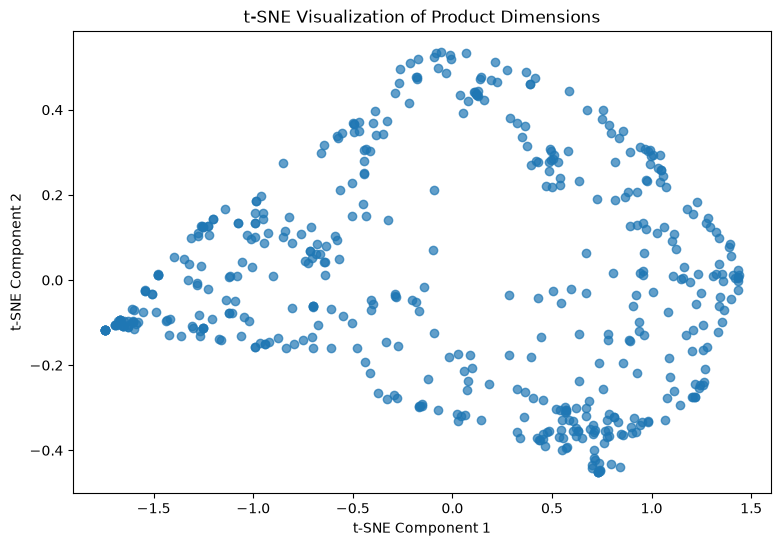

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Select the product features
features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# 2. Remove missing values
tsne_data = products_df[features].dropna().copy()

print("Available rows:", len(tsne_data))

# 3. Take only 500 rows for faster processing
tsne_sample = tsne_data.sample(
    n=min(500, len(tsne_data)),
    random_state=42
)

print("Rows used for t-SNE:", len(tsne_sample))

# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tsne_sample)

print("Scaling completed")

# 5. Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42,
    max_iter=250
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE completed!")

# 6. Plot
plt.figure(figsize=(9, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    alpha=0.7
)

plt.title("t-SNE Visualization of Product Dimensions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [ ]:
t-SNE was applied to visualize the similarity and distribution of products based on their physical dimensions. The product features were standardized before applying t-SNE. A sample of 500 records was used to reduce computation time. The resulting two-dimensional plot helps identify groups and patterns among products based on their dimensions.

In [ ]:
6️⃣ UMAP

In [ ]:
UMAP is another dimensionality-reduction technique. It is generally faster than t-SNE and can preserve both local and some broader structure in the data.

In [25]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\VIDYAPRIYA V\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\VIDYAPRIYA V\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available rows: 32949
Scaling completed


C:\Users\VIDYAPRIYA V\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed!


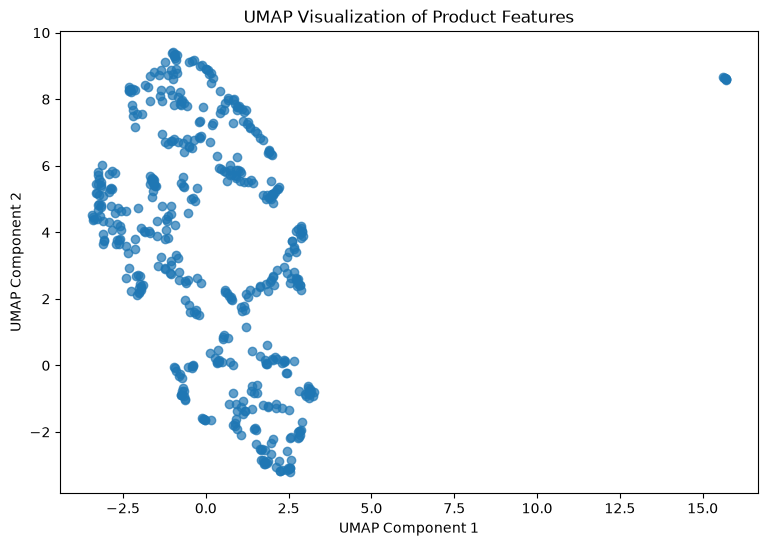

In [26]:
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select features
features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Remove missing values
umap_data = products_df[features].dropna().copy()

print("Available rows:", len(umap_data))

# Use 500 rows for faster processing
umap_sample = umap_data.sample(
    n=min(500, len(umap_data)),
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(umap_sample)

print("Scaling completed")

# Apply UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

print("UMAP completed!")

# Plot
plt.figure(figsize=(9, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.7
)

plt.title("UMAP Visualization of Product Features")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

Starting UMAP...
UMAP completed!


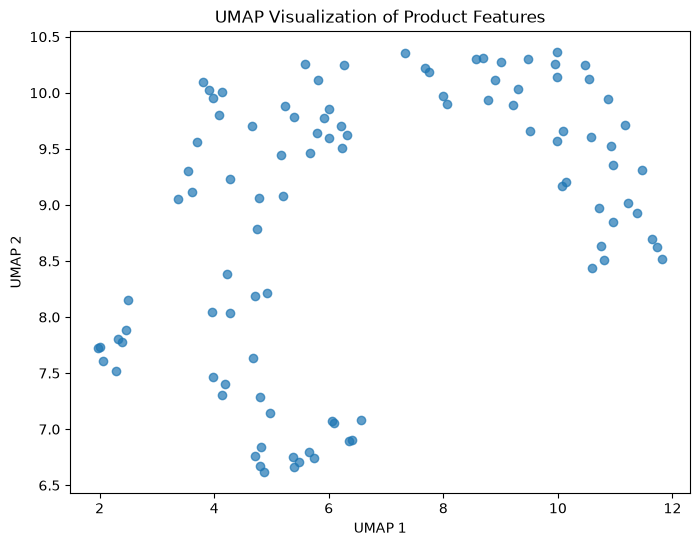

In [28]:
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Only 100 rows
data = products_df[features].dropna().sample(
    n=100,
    random_state=42
)

# Scale
X = StandardScaler().fit_transform(data)

print("Starting UMAP...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    random_state=None
)

X_umap = reducer.fit_transform(X)

print("UMAP completed!")

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7)
plt.title("UMAP Visualization of Product Features")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [ ]:
t-SNE: t-SNE was applied to reduce multiple numerical product attributes into two dimensions for visual exploration of similarity and potential clusters.

UMAP: UMAP was applied as an alternative dimensionality-reduction technique to represent high-dimensional product features in two dimensions while preserving important data structure.

Note: t-SNE and UMAP are mainly useful here for visualization/exploration, rather than automatically creating better ML features.

In [ ]:
1️⃣2️⃣ Final Feature Engineering Dataset

In [172]:
ml_orders = orders_df[
    [
        'order_id',
        'customer_id',
        'order_status',
        'purchase_year',
        'purchase_month',
        'purchase_dayofweek',
        'purchase_hour',
        'is_weekend',
        'actual_delivery_days',
        'estimated_delivery_days',
        'delivery_delay_days',
        'delivery_performance'
    ]
].copy()

print(ml_orders.head())
print(ml_orders.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status  purchase_year  purchase_month  purchase_dayofweek  \
0    delivered           2017              10                   0   
1    delivered           2018               7                   1   
2    delivered           2018               8                   2   
3    delivered           2017              11                   5   
4    delivered           2018               2                   1   

   purchase_hour  is_weekend  actual_delivery_days  estimated_delivery_days  \
0             10           0              8.436806                1

In [ ]:
Feature Engineering: Feature engineering was performed to transform the cleaned Olist data into meaningful analytical and machine-learning features. Time-based features such as year, month, day of week, hour, and weekend indicators were derived from order timestamps. Delivery-related features including actual delivery duration, estimated delivery duration, delivery delay, and delivery performance were created. Ratio and aggregation features were also generated where appropriate. Categorical variables were converted into numerical representations using suitable encoding techniques. Numerical features were scaled when required by the selected machine-learning algorithms. Correlation and variance-based techniques were considered for feature selection, while PCA was evaluated for dimensionality reduction where appropriate.

In [ ]:
But for an actual ML model, target encoding should be calculated only from the training data, not the entire dataset. Otherwise, information from the test set can leak into the training process.

For your report, you can write:

Target Encoding: Categorical variables were converted into numerical representations using the mean target value associated with each category. This technique was considered for categorical features with meaningful relationships to a numerical target variable.

In [ ]:
9. Analyzing Correlation

In [ ]:
Step                                   Purpose
Pearson Correlation                    Measures linear relationships between continuous variables.
Spearman Correlation                   Used for monotonic relationships (even if non-linear).
Kendall’s Tau                          Works well for ordinal variables and small datasets.
Heatmap                                Best for a quick correlation overview.
Pair Plot                              Helps in visualizing relationships between features.
Feature Selection                      Drop highly correlated features to avoid redundancy & multicollinearity.



In [ ]:
## Pearson Correlation 

In [30]:
import pandas as pd
import numpy as np

numerical_cols = [
    'price',
    'freight_value'
]

pearson_corr = order_items_df[numerical_cols].corr(
    method='pearson'
)

print("Pearson Correlation:")
print(pearson_corr)

Pearson Correlation:
                  price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


In [ ]:
## 2. Spearman Correlation

In [31]:
spearman_corr = order_items_df[numerical_cols].corr(
    method='spearman'
)

print("Spearman Correlation:")
print(spearman_corr)

Spearman Correlation:
                 price  freight_value
price          1.00000        0.43419
freight_value  0.43419        1.00000


In [ ]:
## 3. Kendall's Tau

In [32]:
kendall_corr = order_items_df[numerical_cols].corr(
    method='kendall'
)

print("Kendall's Tau:")
print(kendall_corr)

Kendall's Tau:
                  price  freight_value
price          1.000000       0.300516
freight_value  0.300516       1.000000


In [ ]:
## 4. Correlation Heatmap

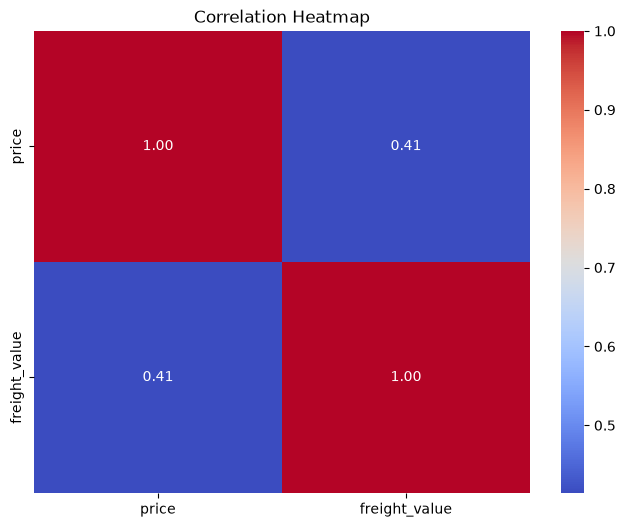

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    order_items_df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
## 5. Pair Plot

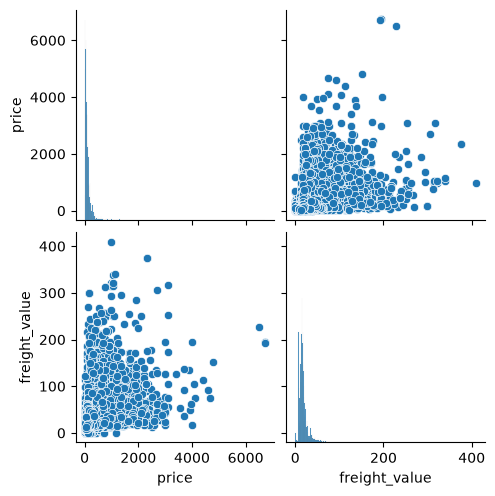

In [34]:
pairplot_cols = [
    'price',
    'freight_value'
]

sns.pairplot(
    order_items_df[pairplot_cols].dropna()
)

plt.show()

In [ ]:
## 6. Find Highly Correlated Features

In [ ]:
## 7. Feature Selection

In [38]:
# Example only
# products_df = products_df.drop(
#     columns=['feature_to_remove']
# )

In [39]:
product_numeric = products_df.select_dtypes(include='number')

corr_matrix = product_numeric.corr(method='pearson')

print(corr_matrix.round(3))

                            product_name_lenght  product_description_lenght  \
product_name_lenght                       1.000                       0.099   
product_description_lenght                0.099                       1.000   
product_photos_qty                        0.134                       0.109   
product_weight_g                          0.045                       0.062   
product_length_cm                         0.081                       0.035   
product_height_cm                        -0.016                       0.064   
product_width_cm                          0.071                      -0.031   

                            product_photos_qty  product_weight_g  \
product_name_lenght                      0.134             0.045   
product_description_lenght               0.109             0.062   
product_photos_qty                       1.000             0.037   
product_weight_g                         0.037             1.000   
product_length_cm          

In [40]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(10))

product_weight_g            product_height_cm             0.563910
product_length_cm           product_width_cm              0.542409
product_weight_g            product_width_cm              0.527597
                            product_length_cm             0.476813
product_height_cm           product_width_cm              0.313491
product_length_cm           product_height_cm             0.204889
product_name_lenght         product_photos_qty            0.134321
product_description_lenght  product_photos_qty            0.108745
product_name_lenght         product_description_lenght    0.098741
                            product_length_cm             0.080556
dtype: float64


In [42]:
import pandas as pd
import numpy as np

product_numeric = products_df.select_dtypes(include='number')

corr_matrix = product_numeric.corr(method='pearson')

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= 0.80:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': correlation
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

print(high_corr_df)

Empty DataFrame
Columns: []
Index: []


In [43]:
import numpy as np

product_numeric = products_df.select_dtypes(include='number')

corr_matrix = product_numeric.corr()

print(corr_matrix.round(2))

                            product_name_lenght  product_description_lenght  \
product_name_lenght                        1.00                        0.10   
product_description_lenght                 0.10                        1.00   
product_photos_qty                         0.13                        0.11   
product_weight_g                           0.04                        0.06   
product_length_cm                          0.08                        0.03   
product_height_cm                         -0.02                        0.06   
product_width_cm                           0.07                       -0.03   

                            product_photos_qty  product_weight_g  \
product_name_lenght                       0.13              0.04   
product_description_lenght                0.11              0.06   
product_photos_qty                        1.00              0.04   
product_weight_g                          0.04              1.00   
product_length_cm          

In [44]:
threshold = 0.80

high_corr_pairs = (
    corr_pairs[abs(corr_pairs) >= threshold]
)

print("Highly Correlated Feature Pairs:")
print(high_corr_pairs)

Highly Correlated Feature Pairs:
Series([], dtype: float64)


In [ ]:
## 7. Feature Selection

In [45]:
# Feature Selection based on correlation

threshold = 0.80

high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= threshold:
            high_corr_features.add(corr_matrix.columns[j])

print("Features to drop:")
print(high_corr_features)

# Create selected dataset
products_selected = products_df.drop(
    columns=list(high_corr_features)
)

print("\nOriginal shape:", products_df.shape)
print("Selected shape:", products_selected.shape)

Features to drop:
set()

Original shape: (32951, 9)
Selected shape: (32951, 9)


In [ ]:
Interpretation
Original features: 9 columns
Highly correlated features: None
Features removed: 0
Final features: 9 columns
Rows: 32,951

Because no correlation exceeded 0.80, there was no need to remove any feature.

In [ ]:
No highly correlated feature pairs were identified using the |r| ≥ 0.80 threshold. Therefore, no numerical features were removed based on correlation analysis.

In [ ]:
Feature Selection: Pearson correlation analysis was performed on the numerical product features. The highest observed correlations were between product_weight_g and product_height_cm (0.56), product_length_cm and product_width_cm (0.54), and product_weight_g and product_width_cm (0.53). Since none of the feature pairs exceeded the selected threshold of |r| ≥ 0.80, no features were removed based on correlation.

10. Transforming and Scaling Data


In [ ]:
Machine learning models perform better when features have a consistent scale and distribution. Transformation and scaling ensure:
✔ Improved Model Performance – Reduces bias toward large values.
✔ Faster Convergence – Optimizers like gradient descent work better.
✔ Better Interpretability – Some models assume normally distributed data.


In [ ]:
Technique                                    Effect                               Best Use Case
Min-Max Scaling                      Scales between 0 and 1                When data has fixed bounds.
Standardization (Z-score)            Mean = 0, Std Dev = 1                 Data is normally distributed.
Robust Scaling                       Uses median and IQR                   Data contains outliers.
Log Transformation                   Reduces right skewness                Highly skewed positive data.
Power Transformation                 Makes data normal-like                When data isn’t normally distributed.



In [ ]:
## Min-Max Scaling

In [46]:
from sklearn.preprocessing import MinMaxScaler

features = ['price', 'freight_value']

minmax_scaler = MinMaxScaler()

order_items_minmax = order_items_df.copy()

order_items_minmax[features] = minmax_scaler.fit_transform(
    order_items_minmax[features]
)

print(order_items_minmax[features].head())

      price  freight_value
0  0.008620       0.032440
1  0.035498       0.048648
2  0.029425       0.043619
3  0.001803       0.031219
4  0.029558       0.044278


In [47]:
print(order_items_minmax[features].min())
print(order_items_minmax[features].max())

price            0.0
freight_value    0.0
dtype: float64
price            1.0
freight_value    1.0
dtype: float64


In [ ]:
## 2. Standardization (Z-score)

In [48]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

order_items_standard = order_items_df.copy()

order_items_standard[features] = standard_scaler.fit_transform(
    order_items_standard[features]
)

print(order_items_standard[features].head())

      price  freight_value
0 -0.336289      -0.423901
1  0.649372      -0.003816
2  0.426646      -0.134144
3 -0.586298      -0.455534
4  0.431547      -0.117062


In [49]:
print("Mean:")
print(order_items_standard[features].mean())

print("\nStandard Deviation:")
print(order_items_standard[features].std())

Mean:
price            4.465728e-17
freight_value   -1.135355e-17
dtype: float64

Standard Deviation:
price            1.000004
freight_value    1.000004
dtype: float64


In [ ]:
## 3. Robust Scaling

In [50]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

order_items_robust = order_items_df.copy()

order_items_robust[features] = robust_scaler.fit_transform(
    order_items_robust[features]
)

print(order_items_robust[features].head())

      price  freight_value
0 -0.169368      -0.368030
1  1.735895       0.454771
2  1.305368       0.199504
3 -0.652632      -0.429988
4  1.314842       0.232962


In [51]:
print(order_items_robust[features].describe())

               price  freight_value
count  112650.000000  112650.000000
mean        0.480671       0.462245
std         1.932989       1.958662
min        -0.780421      -2.014870
25%        -0.369368      -0.394052
50%         0.000000       0.000000
75%         0.630632       0.605948
max        70.105368      48.750929


In [ ]:
## 4. Log Transformation

In [52]:
import numpy as np

order_items_log = order_items_df.copy()

order_items_log['price_log'] = np.log1p(
    order_items_log['price']
)

order_items_log['freight_value_log'] = np.log1p(
    order_items_log['freight_value']
)

print(
    order_items_log[
        ['price', 'price_log',
         'freight_value', 'freight_value_log']
    ].head(10)
)

    price  price_log  freight_value  freight_value_log
0   58.90   4.092677          13.29           2.659560
1  239.90   5.484382          19.93           3.041184
2  199.00   5.298317          17.87           2.937573
3   12.99   2.638343          12.79           2.623944
4  199.90   5.302807          18.14           2.951780
5   21.90   3.131137          12.69           2.616666
6   19.90   3.039749          11.85           2.553344
7  810.00   6.698268          70.75           4.273188
8  145.95   4.990092          11.65           2.537657
9   53.99   4.007151          11.40           2.517696


In [53]:
print("Original price skewness:",
      order_items_df['price'].skew())

print("Log price skewness:",
      order_items_log['price_log'].skew())

print("\nOriginal freight skewness:",
      order_items_df['freight_value'].skew())

print("Log freight skewness:",
      order_items_log['freight_value_log'].skew())

Original price skewness: 7.9232082632135095
Log price skewness: 0.2935289843968638

Original freight skewness: 5.639869620428685
Log freight skewness: 0.0011106960636092708


In [ ]:
## 5. Power Transformation

In [54]:
from sklearn.preprocessing import PowerTransformer

power_transformer = PowerTransformer(
    method='yeo-johnson'
)

order_items_power = order_items_df.copy()

order_items_power[features] = power_transformer.fit_transform(
    order_items_power[features]
)

print(order_items_power[features].head())

      price  freight_value
0 -0.230070      -0.440164
1  1.247218       0.284404
2  1.061021       0.087691
3 -2.001411      -0.507790
4  1.065553       0.114665


In [55]:
print("Original skewness:")
print(order_items_df[features].skew())

print("\nAfter Power Transformation:")
print(order_items_power[features].skew())

Original skewness:
price            7.923208
freight_value    5.639870
dtype: float64

After Power Transformation:
price           -0.006516
freight_value   -0.000213
dtype: float64


In [ ]:
## 6. Compare the transformations

In [56]:
comparison = pd.DataFrame({
    'Original': order_items_df[features].skew(),
    'MinMax': order_items_minmax[features].skew(),
    'Standardized': order_items_standard[features].skew(),
    'Robust': order_items_robust[features].skew(),
    'Log': order_items_log[
        ['price_log', 'freight_value_log']
    ].skew().values,
    'Power': order_items_power[features].skew()
}, index=features)

print(comparison)

               Original    MinMax  Standardized    Robust       Log     Power
price          7.923208  7.923208      7.923208  7.923208  0.293529 -0.006516
freight_value  5.639870  5.639870      5.639870  5.639870  0.001111 -0.000213


In [ ]:
Transforming and Scaling Data: Min-Max Scaling, Standardization, Robust Scaling, Log Transformation, and Power Transformation were applied to appropriate numerical features. Scaling techniques were used to bring variables to comparable numerical ranges, while Log and Power transformations were evaluated for reducing skewness. The transformation producing a more suitable distribution can be selected according to the requirements of the machine learning algorithm.


11. Reducing Dimensionality


In [ ]:
High-dimensional data can lead to:
 ✔ Curse of Dimensionality – More dimensions → Sparse data → Poor model performance.
 ✔ Longer Training Time – More features increase computational cost.
 ✔ Overfitting – Too many irrelevant features can make models complex.
Reducing dimensionality improves efficiency while retaining key information.


In [ ]:
Method                               Type                                                Best Use Case 
Feature Selection                    Removes irrelevant features                         When some features add no value.
PCA                                  Transforms data into principal components           When features are correlated.
LDA                                  Maximizes class separability                        Classification tasks.
t-SNE                                Preserves local structure in 2D/3D                  Data visualization.
Autoencoders                         Learns compressed representations                   Deep learning & non-linear data.  



In [ ]:
## Feature Selection

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Select data
pca_data = products_df[features].dropna()

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

        PC1       PC2
0  5.726576  1.385814
1  1.485944  0.554111
2 -1.665751 -0.032261
3  1.012512 -1.052610
4 -1.103689  0.845361

Explained Variance Ratio:
[0.5829198  0.21736809]

Total Variance Explained:
0.8002878852506443


In [ ]:
Feature Selection: Highly correlated numerical features were identified using a correlation threshold of |r| ≥ 0.80. No feature pairs exceeded the threshold; therefore, no features were removed and all 9 features were retained for further analysis and machine learning.

In [ ]:
No features were removed because none of the numerical feature pairs had a correlation of 0.80 or higher.

So:

Before: 9 features
Removed: 0
After: 9 features

In [ ]:
## PCA — Principal Component Analysis

In [59]:
features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Select data
pca_data = products_df[features].dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

        PC1       PC2
0  5.726576  1.385814
1  1.485944  0.554111
2 -1.665751 -0.032261
3  1.012512 -1.052610
4 -1.103689  0.845361

Explained Variance Ratio:
[0.5829198  0.21736809]

Total Variance Explained:
0.8002878852506443


In [ ]:
## PCA Visualization

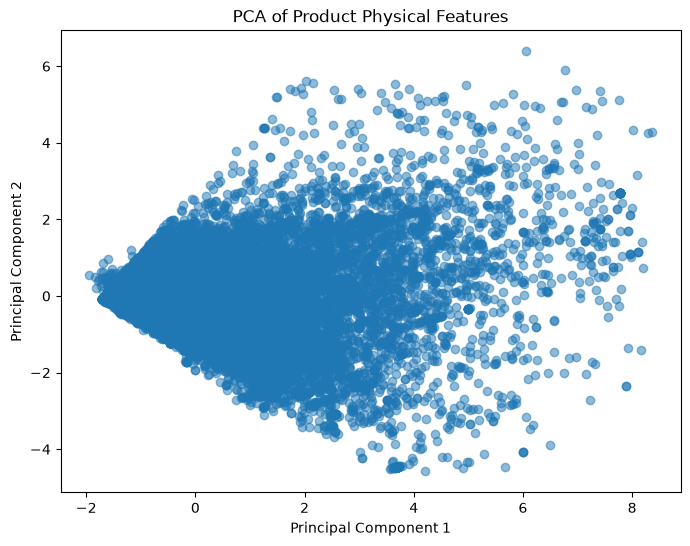

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Product Physical Features')

plt.show()

In [ ]:
## LDA — Linear Discriminant Analysis

In [62]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(
    n_components=2
)

lda_result = lda.fit_transform(
    X,
    y
)

In [63]:
print("Original shape:", X.shape)
print("LDA shape:", lda_result.shape)

Original shape: (32949, 3)
LDA shape: (32949, 2)


In [ ]:
32,949 rows → you processed 32,949 products.
3 original features → X contained 3 input features.
2 LDA components → LDA reduced those 3 features to 2 dimensions.

In [ ]:
## 

In [65]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

# Take a sample of 5,000 products
tsne_data = products_df[features].dropna().sample(
    n=5000,
    random_state=42
)

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(tsne_data)

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=500
)

tsne_result = tsne.fit_transform(scaled_data)

# Create DataFrame
tsne_df = pd.DataFrame(
    tsne_result,
    columns=['tSNE1', 'tSNE2']
)

print(tsne_df.head())

       tSNE1      tSNE2
0   9.336077 -38.269131
1 -23.933651  19.177748
2  -0.072908  23.059118
3   8.809010  15.219091
4 -18.332470  25.662136


In [ ]:
## Autoencoders

In [ ]:
Feature 1 ──┐
Feature 2 ──┼──> Encoder ──> 2D compressed representation ──> Decoder ──> Original 3 features
Feature 3 ──┘

In [ ]:
Why use Autoencoders?
    
| Technique       | Main purpose                                               |
| --------------- | ---------------------------------------------------------- |
| PCA             | Linear dimensionality reduction                            |
| t-SNE           | Visualization of complex relationships                     |
| UMAP            | Non-linear dimensionality reduction                        |
| LDA             | Reduce dimensions while separating classes                 |
| **Autoencoder** | **Learn compressed representations using neural networks** |


In [66]:
## scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (32949, 3)


In [70]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\VIDYAPRIYA V\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [71]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [72]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_layer = Input(shape=(3,))

encoded = Dense(2, activation='relu')(input_layer)

decoded = Dense(3, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
## Train the encoder
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.1151 - val_loss: 0.6762
Epoch 2/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6882 - val_loss: 0.4392
Epoch 3/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5103 - val_loss: 0.3175
Epoch 4/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4016 - val_loss: 0.2394
Epoch 5/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3142 - val_loss: 0.1744
Epoch 6/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2480 - val_loss: 0.1318
Epoch 7/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2080 - val_loss: 0.1044
Epoch 8/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1838 - val_loss: 0.0909
Epoch 9/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1721 - val_loss: 0.0852
Epoch 10/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1681 - val_loss: 0.0832
Epoch 11/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1667 - val_loss: 0.0814
Epoch 12/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [74]:
## Extract the compressed features
encoder = Model(
    input_layer,
    encoded
)

autoencoder_result = encoder.predict(X_scaled)

print("Original shape:", X_scaled.shape)
print("Autoencoder shape:", autoencoder_result.shape)

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Original shape: (32949, 3)
Autoencoder shape: (32949, 2)


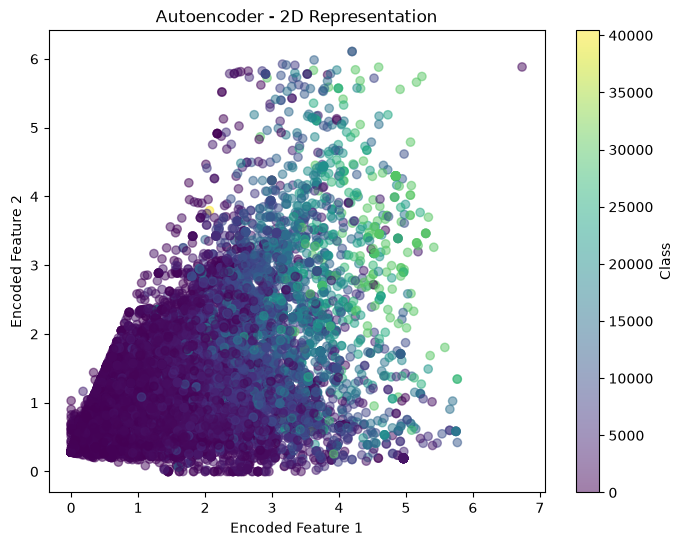

In [75]:
## visualize the Autoencoder result
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    autoencoder_result[:, 0],
    autoencoder_result[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("Encoded Feature 1")
plt.ylabel("Encoded Feature 2")
plt.title("Autoencoder - 2D Representation")
plt.colorbar(label="Class")

plt.show()

In [ ]:
X‑axis (Encoded Feature 1) and Y‑axis (Encoded Feature 2):
These are the two latent features learned by the autoencoder — compressed representations of your original high‑dimensional input data.

Color scale (Class):
Each point’s color corresponds to its class label or target value, ranging roughly from 0 to 40 000.

📊 What it means
The autoencoder has reduced your data to two dimensions while preserving structure.

Points with similar colors cluster together, meaning the model has captured meaningful patterns — similar inputs are encoded close to each other.

The triangular or fan‑shaped spread suggests one latent dimension varies more strongly than the other, possibly representing a dominant feature in your dataset.

In [76]:
import os

cleaned_path = r"D:\HCL_PROJECTS\Cart2 Insight\Data\cleaned1"

os.makedirs(cleaned_path, exist_ok=True)

print("Cleaned data folder created:")
print(cleaned_path)

Cleaned data folder created:
D:\HCL_PROJECTS\Cart2 Insight\Data\cleaned1


In [78]:
import pandas as pd
import os

cleaned_path = r"D:\HCL_PROJECTS\Cart2 Insight\Data\cleaned"

customers_df = pd.read_csv(
    os.path.join(cleaned_path, "customers_cleaned.csv")
)

geolocation_df = pd.read_csv(
    os.path.join(cleaned_path, "geolocation_cleaned.csv")
)

order_items_df = pd.read_csv(
    os.path.join(cleaned_path, "order_items_cleaned.csv")
)

order_payments_df = pd.read_csv(
    os.path.join(cleaned_path, "order_payments_cleaned.csv")
)

order_reviews_df = pd.read_csv(
    os.path.join(cleaned_path, "order_reviews_cleaned.csv")
)

orders_df = pd.read_csv(
    os.path.join(cleaned_path, "orders_cleaned.csv")
)

products_df = pd.read_csv(
    os.path.join(cleaned_path, "products_cleaned.csv")
)

sellers_df = pd.read_csv(
    os.path.join(cleaned_path, "sellers_cleaned.csv")
)

category_translation_df = pd.read_csv(
    os.path.join(cleaned_path, "category_translation_cleaned.csv")
)

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


In [79]:
print("Customers:", customers_df.shape)
print("Geolocation:", geolocation_df.shape)
print("Order Items:", order_items_df.shape)
print("Order Payments:", order_payments_df.shape)
print("Order Reviews:", order_reviews_df.shape)
print("Orders:", orders_df.shape)
print("Products:", products_df.shape)
print("Sellers:", sellers_df.shape)
print("Category Translation:", category_translation_df.shape)

Customers: (99441, 5)
Geolocation: (738327, 5)
Order Items: (112650, 7)
Order Payments: (103886, 6)
Order Reviews: (99224, 7)
Orders: (99441, 14)
Products: (32951, 11)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [80]:
print("customers_df" in globals())
print("geolocation_df" in globals())
print("order_items_df" in globals())
print("order_payments_df" in globals())
print("order_reviews_df" in globals())
print("orders_df" in globals())
print("products_df" in globals())
print("sellers_df" in globals())
print("category_translation_df" in globals())

True
True
True
True
True
True
True
True
True


In [81]:
import os

cleaned_path = r"D:\HCL_PROJECTS\Cart2 Insight\Data\cleaned1"

os.makedirs(cleaned_path, exist_ok=True)

datasets = {
    "customers": customers_df,
    "geolocation": geolocation_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "order_reviews": order_reviews_df,
    "orders": orders_df,
    "products": products_df,
    "sellers": sellers_df,
    "category_translation": category_translation_df
}

for name, df in datasets.items():
    file_path = os.path.join(
        cleaned_path,
        name + "_cleaned.csv"
    )
    
    df.to_csv(file_path, index=False)
    
    print(f"Saved: {name}_cleaned.csv | Shape: {df.shape}")

print("\nAll cleaned datasets saved successfully.")

Saved: customers_cleaned.csv | Shape: (99441, 5)
Saved: geolocation_cleaned.csv | Shape: (738327, 5)
Saved: order_items_cleaned.csv | Shape: (112650, 7)
Saved: order_payments_cleaned.csv | Shape: (103886, 6)
Saved: order_reviews_cleaned.csv | Shape: (99224, 7)
Saved: orders_cleaned.csv | Shape: (99441, 14)
Saved: products_cleaned.csv | Shape: (32951, 11)
Saved: sellers_cleaned.csv | Shape: (3095, 4)
Saved: category_translation_cleaned.csv | Shape: (71, 2)

All cleaned datasets saved successfully.
